<a href="https://colab.research.google.com/github/yoojinko24/Climate_Change_Rice_Production/blob/main/Climate_Change_Rice_Production.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 필요한 라이브러리, 폰트 설치

In [1]:
# 구글 드라이브와 연동

from google.colab import drive
drive.mount('/content/gdrive')
directory_path = '/content/gdrive/My Drive/Colab Notebooks/rice_production_datasets/'

# 데이터처리 라이브러리 불러오기

import numpy as np
import pandas as pd
import csv
import seaborn as sns
import matplotlib.pyplot as plt
from xml.etree import ElementTree as ET


# fm._rebuild() # _rebuild() 함수는 최신 matplotlib 버전에서 제거되었습니다.
plt.rc('font', family='NanumGothic')

Mounted at /content/gdrive


In [2]:
!pip install shap

# 나눔 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# matplotlib 폰트 설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# fm._rebuild() # _rebuild() 함수는 최신 matplotlib 버전에서 제거되었습니다.
plt.rc('font', family='NanumGothic')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

# 쌀 생산량, 면적당 생산량, 재배면적

In [3]:
from pandas import json_normalize
import requests

json_Url = 'https://kosis.kr/openapi/Param/statisticsParameterData.do?method=getList&apiKey=YmRmZGE4NzJkOGE5YzE0Y2M3OGFmZjFiNjcxMjdkYzA=&itmId=T03+T06+T09+T12+T15+T18+T21+T24+&objL1=ALL&objL2=&objL3=&objL4=&objL5=&objL6=&objL7=&objL8=&format=json&jsonVD=Y&prdSe=Y&startPrdDe=2010&endPrdDe=2024&orgId=101&tblId=DT_1ET0221'


In [4]:
# 데이터 요청 정상여부 확인 <Response [200]> 결과값 = '요청 성공'
test = requests.get(json_Url)
test
# JSON데이터 가져오기
test_data = test.json()
test_data
# pandas 활용 데이터 형태 변환
df_rice = pd.json_normalize(test_data)
df_rice

,C1_OBJ_NM,DT,C1,PRD_SE,UNIT_NM_ENG,ITM_ID,TBL_ID,ITM_NM,TBL_NM,PRD_DE,LST_CHN_DE,C1_NM_ENG,C1_NM,UNIT_NM,ITM_NM_ENG,ORG_ID,C1_OBJ_NM_ENG
0,시도별,892074,00,A,ha,T03,DT_1ET0221,합계:면적,미곡생산량(백미92.9%),2010,2011-05-31,Total,계,ha,Total:Area,101,By province
1,시도별,853823,00,A,ha,T03,DT_1ET0221,합계:면적,미곡생산량(백미92.9%),2011,2011-11-16,Total,계,ha,Total:Area,101,By province
2,시도별,849172,00,A,ha,T03,DT_1ET0221,합계:면적,미곡생산량(백미92.9%),2012,2012-11-16,Total,계,ha,Total:Area,101,By province
3,시도별,832625,00,A,ha,T03,DT_1ET0221,합계:면적,미곡생산량(백미92.9%),2013,2013-11-14,Total,계,ha,Total:Area,101,By province
4,시도별,815506,00,A,ha,T03,DT_1ET0221,합계:면적,미곡생산량(백미92.9%),2014,2015-11-13,Total,계,ha,Total:Area,101,By province
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2107,시도별,51.7615,39,A,Ton,T24,DT_1ET0221,밭벼:생산량,미곡생산량(백미92.9%),2020,2020-11-11,Jeju-do,제주도,톤,Production,101,By province
2108,시도별,168.2146,39,A,Ton,T24,DT_1ET0221,밭벼:생산량,미곡생산량(백미92.9%),2021,2022-02-16,Jeju-do,제주도,톤,Production,101,By province
2109,시도별,182.8257,39,A,Ton,T24,DT_1ET0221,밭벼:생산량,미곡생산량(백미92.9%),2022,2022-11-10,Jeju-do,제주도,톤,Production,101,By province
2110,시도별,0,39,A,Ton,T24,DT_1ET0221,밭벼:생산량,미곡생산량(백미92.9%),2023,2023-11-09,Jeju-do,제주도,톤,Production,101,By province


In [5]:
# 삭제할 컬럼 목록
columns_to_drop = ['C1_OBJ_NM', 'C1_NM_ENG', 'ITM_NM_ENG', 'ORG_ID', 'C1_OBJ_NM_ENG']

# 컬럼 삭제
df_rice_processed = df_rice.drop(columns=columns_to_drop)

# 'C1' 컬럼의 값이 '00' 이거나 31부터 38까지인 행만 필터링
# 'C1' 컬럼이 문자열 타입이므로 문자열 비교를 사용합니다.
df_rice_processed = df_rice_processed[
    (df_rice_processed['C1'] == '00') | ((df_rice_processed['C1'] >= '31') & (df_rice_processed['C1'] <= '38'))
].copy()

print("전처리된 df_rice_processed 데이터프레임의 처음 5개 행:")
display(df_rice_processed.head())

print("\n전처리된 df_rice_processed 데이터프레임의 정보:")
df_rice_processed.info()

전처리된 df_rice_processed 데이터프레임의 처음 5개 행:


,DT,C1,PRD_SE,UNIT_NM_ENG,ITM_ID,TBL_ID,ITM_NM,TBL_NM,PRD_DE,LST_CHN_DE,C1_NM,UNIT_NM
0,892074,00,A,ha,T03,DT_1ET0221,합계:면적,미곡생산량(백미92.9%),2010,2011-05-31,계,ha
1,853823,00,A,ha,T03,DT_1ET0221,합계:면적,미곡생산량(백미92.9%),2011,2011-11-16,계,ha
2,849172,00,A,ha,T03,DT_1ET0221,합계:면적,미곡생산량(백미92.9%),2012,2012-11-16,계,ha
3,832625,00,A,ha,T03,DT_1ET0221,합계:면적,미곡생산량(백미92.9%),2013,2013-11-14,계,ha
4,815506,00,A,ha,T03,DT_1ET0221,합계:면적,미곡생산량(백미92.9%),2014,2015-11-13,계,ha



전처리된 df_rice_processed 데이터프레임의 정보:
<class 'pandas.core.frame.DataFrame'>
Index: 1080 entries, 0 to 1991
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   DT           1080 non-null   object
 1   C1           1080 non-null   object
 2   PRD_SE       1080 non-null   object
 3   UNIT_NM_ENG  1080 non-null   object
 4   ITM_ID       1080 non-null   object
 5   TBL_ID       1080 non-null   object
 6   ITM_NM       1080 non-null   object
 7   TBL_NM       1080 non-null   object
 8   PRD_DE       1080 non-null   object
 9   LST_CHN_DE   1080 non-null   object
 10  C1_NM        1080 non-null   object
 11  UNIT_NM      1080 non-null   object
dtypes: object(12)
memory usage: 109.7+ KB


In [6]:
# '밭벼' 관련 데이터를 제외합니다.
df_rice_filtered = df_rice_processed[~df_rice_processed['ITM_NM'].str.contains('밭벼')].copy()

# '면적' 데이터프레임 생성
df_rice_area = df_rice_filtered[df_rice_filtered['ITM_NM'] == '합계:면적'].copy()

# '10a당 생산량' 데이터프레임 생성 (논벼만 해당)
df_rice_area_production = df_rice_filtered[df_rice_filtered['ITM_NM'] == '논벼:10a당 생산량'].copy()

# '생산량' 데이터프레임 생성 (합계, 논벼 포함)
df_rice_production = df_rice_filtered[df_rice_filtered['ITM_NM'].isin(['합계:생산량', '논벼:생산량'])].copy()

print("df_rice_area의 처음 5개 행:")
display(df_rice_area.head())

print("\ndf_rice_area_production의 처음 5개 행:")
display(df_rice_area_production.head())

print("\ndf_rice_production의 처음 5개 행:")
display(df_rice_production.head())

df_rice_area의 처음 5개 행:


,DT,C1,PRD_SE,UNIT_NM_ENG,ITM_ID,TBL_ID,ITM_NM,TBL_NM,PRD_DE,LST_CHN_DE,C1_NM,UNIT_NM
0,892074,00,A,ha,T03,DT_1ET0221,합계:면적,미곡생산량(백미92.9%),2010,2011-05-31,계,ha
1,853823,00,A,ha,T03,DT_1ET0221,합계:면적,미곡생산량(백미92.9%),2011,2011-11-16,계,ha
2,849172,00,A,ha,T03,DT_1ET0221,합계:면적,미곡생산량(백미92.9%),2012,2012-11-16,계,ha
3,832625,00,A,ha,T03,DT_1ET0221,합계:면적,미곡생산량(백미92.9%),2013,2013-11-14,계,ha
4,815506,00,A,ha,T03,DT_1ET0221,합계:면적,미곡생산량(백미92.9%),2014,2015-11-13,계,ha



df_rice_area_production의 처음 5개 행:


,DT,C1,PRD_SE,UNIT_NM_ENG,ITM_ID,TBL_ID,ITM_NM,TBL_NM,PRD_DE,LST_CHN_DE,C1_NM,UNIT_NM
45,482.98385,00,A,kg,T12,DT_1ET0221,논벼:10a당 생산량,미곡생산량(백미92.9%),2010,2013-06-05,계,kg
46,495.60607,00,A,kg,T12,DT_1ET0221,논벼:10a당 생산량,미곡생산량(백미92.9%),2011,2013-06-05,계,kg
47,472.58184,00,A,kg,T12,DT_1ET0221,논벼:10a당 생산량,미곡생산량(백미92.9%),2012,2013-06-05,계,kg
48,508.4902,00,A,kg,T12,DT_1ET0221,논벼:10a당 생산량,미곡생산량(백미92.9%),2013,2013-11-14,계,kg
49,520.36854,00,A,kg,T12,DT_1ET0221,논벼:10a당 생산량,미곡생산량(백미92.9%),2014,2015-11-13,계,kg



df_rice_production의 처음 5개 행:


,DT,C1,PRD_SE,UNIT_NM_ENG,ITM_ID,TBL_ID,ITM_NM,TBL_NM,PRD_DE,LST_CHN_DE,C1_NM,UNIT_NM
15,4295413.07073,00,A,Ton,T06,DT_1ET0221,합계:생산량,미곡생산량(백미92.9%),2010,2013-06-05,계,톤
16,4224018.87873,00,A,Ton,T06,DT_1ET0221,합계:생산량,미곡생산량(백미92.9%),2011,2013-06-05,계,톤
17,4006185.31108,00,A,Ton,T06,DT_1ET0221,합계:생산량,미곡생산량(백미92.9%),2012,2013-06-05,계,톤
18,4230011.40748,00,A,Ton,T06,DT_1ET0221,합계:생산량,미곡생산량(백미92.9%),2013,2013-11-14,계,톤
19,4240739.25146,00,A,Ton,T06,DT_1ET0221,합계:생산량,미곡생산량(백미92.9%),2014,2015-11-13,계,톤


In [7]:
df_rice_area.head(135)

,DT,C1,PRD_SE,UNIT_NM_ENG,ITM_ID,TBL_ID,ITM_NM,TBL_NM,PRD_DE,LST_CHN_DE,C1_NM,UNIT_NM
0,892074,00,A,ha,T03,DT_1ET0221,합계:면적,미곡생산량(백미92.9%),2010,2011-05-31,계,ha
1,853823,00,A,ha,T03,DT_1ET0221,합계:면적,미곡생산량(백미92.9%),2011,2011-11-16,계,ha
2,849172,00,A,ha,T03,DT_1ET0221,합계:면적,미곡생산량(백미92.9%),2012,2012-11-16,계,ha
3,832625,00,A,ha,T03,DT_1ET0221,합계:면적,미곡생산량(백미92.9%),2013,2013-11-14,계,ha
4,815506,00,A,ha,T03,DT_1ET0221,합계:면적,미곡생산량(백미92.9%),2014,2015-11-13,계,ha
...,...,...,...,...,...,...,...,...,...,...,...,...
1882,65027.9489,38,A,ha,T03,DT_1ET0221,합계:면적,미곡생산량(백미92.9%),2020,2020-11-11,경상남도,ha
1883,64079.0616,38,A,ha,T03,DT_1ET0221,합계:면적,미곡생산량(백미92.9%),2021,2022-02-16,경상남도,ha
1884,64480.5647,38,A,ha,T03,DT_1ET0221,합계:면적,미곡생산량(백미92.9%),2022,2022-11-10,경상남도,ha
1885,63437.0806,38,A,ha,T03,DT_1ET0221,합계:면적,미곡생산량(백미92.9%),2023,2023-11-09,경상남도,ha


# ASOS 데이터

In [8]:
import pandas as pd

region_name_map = {
    "경기": "gyeonggi",
    "강원": "gangwon",
    "충북": "chungbuk",
    "충남": "chungnam",
    "전북": "jeonbuk",
    "전남": "jeonnam",
    "경북": "gyeongbuk",
    "경남": "gyeongnam",
}



for kor, eng in region_name_map.items():
    file_path = directory_path + f"{kor}_raw_data_plus.csv"

    try:
        globals()[eng] = pd.read_csv(file_path)   # << 변수 자동 생성
        print(f"{eng} 변수 생성 완료")
    except FileNotFoundError:
        print(f"⚠ 파일 없음: {file_path}")


gyeonggi 변수 생성 완료
gangwon 변수 생성 완료
chungbuk 변수 생성 완료
chungnam 변수 생성 완료
jeonbuk 변수 생성 완료
jeonnam 변수 생성 완료
gyeongbuk 변수 생성 완료
gyeongnam 변수 생성 완료


In [9]:
def check_outliers_absolute(df):
    # 절대 범위 기준 정의
    ranges = {
        "평균기온": (-40, 45),
        "최고기온": (-40, 50),
        "최저기온": (-50, 40),
        "강수량": (0, 600),
        "평균지면온도": (-40, 50),
        "평균증기압": (0, 50),
        "합계일사량": (0, 35),
    }

    outlier_report = {}

    for col, (low, high) in ranges.items():
        if col not in df.columns:
            continue

        mask = (df[col] < low) | (df[col] > high)
        outlier_report[col] = mask.sum()  # 이상치 개수

    return pd.DataFrame({
        "column": outlier_report.keys(),
        "outlier_count": outlier_report.values()
    })


In [10]:
def process_region_df(df, region_engname):
    # 절대 범위 기준
    ranges = {
        "평균기온": (-40, 45),
        "최고기온": (-40, 50),
        "최저기온": (-50, 40),
        "강수량": (0, 600),
        "평균지면온도": (-40, 60),
        "평균증기압": (0, 50),
        "합계일사량": (0, 35),
    }

    # 이상치 제거
    for col, (low, high) in ranges.items():
        if col in df.columns:
            df = df[(df[col].between(low, high)) | (df[col].isna())]

    # 날짜 변환
    df["날짜"] = pd.to_datetime(df["날짜"])

    # 강수량 NaN 포함하면 → 결과도 NaN
    def rain_mean_or_nan(x):
        return np.nan if x.isna().any() else x.mean()

    # 그룹바이
    result = df.groupby("날짜").agg({
        "평균기온": "mean",
        "최고기온": "max",
        "최저기온": "min",
        "강수량": rain_mean_or_nan,
        "평균지면온도": "mean",
        "평균증기압": "mean",
        "합계일사량": "mean"
    }).reset_index()

    # 지역명 추가
    result["지역명"] = region_engname

    return result


In [11]:
gyeonggi_clean = process_region_df(gyeonggi, "경기도")
gangwon_clean = process_region_df(gangwon, "강원도")
chungbuk_clean = process_region_df(chungbuk, "충청북도")
chungnam_clean = process_region_df(chungnam, "충청남도")
jeonbuk_clean = process_region_df(jeonbuk, "전라북도")
jeonnam_clean = process_region_df(jeonnam, "전라남도")
gyeongbuk_clean = process_region_df(gyeongbuk, "경상북도")
gyeongnam_clean = process_region_df(gyeongnam, "경상남도")
gyeonggi_clean.head()


,날짜,평균기온,최고기온,최저기온,강수량,평균지면온도,평균증기압,합계일사량,지역명
0,2010-01-01,-9.24,-3.0,-19.4,NaN,-4.36,1.88,8.43,경기도
1,2010-01-02,-3.50,1.3,-11.4,2.16,-1.60,3.76,2.95,경기도
2,2010-01-03,-7.60,-1.2,-18.7,NaN,-2.70,1.98,9.78,경기도
3,2010-01-04,-6.02,-2.4,-12.2,11.56,-1.54,3.32,2.95,경기도
4,2010-01-05,-10.24,-4.7,-19.8,NaN,-2.36,1.94,9.99,경기도


In [12]:
import pandas as pd

# 이미 존재하는 지역별 데이터프레임들
dfs = [
    gyeonggi_clean,
    gangwon_clean,
    chungbuk_clean,
    chungnam_clean,
    jeonbuk_clean,
    jeonnam_clean,
    gyeongbuk_clean,
    gyeongnam_clean
]

# 리스트에 있는 데이터프레임을 모두 세로로 붙이기
all_regions_df = pd.concat(dfs, ignore_index=True)

In [13]:
all_regions_df.head()

,날짜,평균기온,최고기온,최저기온,강수량,평균지면온도,평균증기압,합계일사량,지역명
0,2010-01-01,-9.24,-3.0,-19.4,NaN,-4.36,1.88,8.43,경기도
1,2010-01-02,-3.50,1.3,-11.4,2.16,-1.60,3.76,2.95,경기도
2,2010-01-03,-7.60,-1.2,-18.7,NaN,-2.70,1.98,9.78,경기도
3,2010-01-04,-6.02,-2.4,-12.2,11.56,-1.54,3.32,2.95,경기도
4,2010-01-05,-10.24,-4.7,-19.8,NaN,-2.36,1.94,9.99,경기도


In [14]:
import pandas as pd

df = all_regions_df.copy()

# 1) 날짜에서 연도와 월 추출
df['연도'] = pd.to_datetime(df['날짜']).dt.year
df['월'] = pd.to_datetime(df['날짜']).dt.month

# 2) 월 구간(Period) 생성
def get_period(m):
    if m in [4, 5]:
        return '4_5'
    elif m == 6:
        return '6'
    elif m == 7:
        return '7'
    elif m == 8:
        return '8'
    elif m in [9, 10]:
        return '9_10'
    else:
        return None  # 4~10월 외 월은 제외

df['기간'] = df['월'].apply(get_period)

# 3) 기간이 None인 행 제거 (1~3월, 11~12월)
df = df.dropna(subset=['기간'])

# 4) 우리가 평균 낼 기상 지표들
metrics = [
    '평균기온', '최고기온', '최저기온',
    '강수량', '평균지면온도', '평균증기압', '합계일사량'
]

# 5) 연도 × 지역명 × 기간 별 평균 계산
grouped = df.groupby(['지역명', '연도', '기간'])[metrics].mean().reset_index()

# 6) melt → pivot 으로 wide 변환
melted = grouped.melt(
    id_vars=['지역명', '연도', '기간'],
    value_vars=metrics,
    var_name='지표',
    value_name='값'
)

# 7) 컬럼명: "기간_지표명" 형태로 생성 (예: 4_5_평균기온)
melted['컬럼명'] = melted['기간'] + '_' + melted['지표']

# 8) wide pivot
wide_df = melted.pivot_table(
    index=['지역명', '연도'],
    columns='컬럼명',
    values='값'
).reset_index()

# 9) 컬럼명 정리
wide_df.columns.name = None
wide_df = wide_df.reset_index(drop=True)
wide_df = wide_df.rename(columns={'지역명': '시도명'})

wide_df


,시도명,연도,4_5_강수량,4_5_최고기온,4_5_최저기온,4_5_평균기온,4_5_평균증기압,4_5_평균지면온도,4_5_합계일사량,6_강수량,...,8_평균증기압,8_평균지면온도,8_합계일사량,9_10_강수량,9_10_최고기온,9_10_최저기온,9_10_평균기온,9_10_평균증기압,9_10_평균지면온도,9_10_합계일사량
0,강원도,2010,9.798701,21.496721,2.575410,12.360954,8.357377,14.759911,17.916230,10.386364,...,25.731256,27.488270,12.752581,29.420513,24.250820,7.386885,15.926093,14.482787,18.191667,12.307770
1,강원도,2011,17.274359,22.337705,3.278689,12.825820,8.606694,14.874590,16.850885,41.977778,...,23.605450,26.434409,14.598581,13.886458,23.818033,5.885246,15.119449,12.590561,17.170306,13.213738
2,강원도,2012,12.363194,23.783607,4.155738,14.067213,9.245082,16.624590,18.108525,19.566667,...,24.036022,27.815591,12.853290,24.162963,24.009836,5.832787,15.373361,12.997541,17.600137,13.298492
3,강원도,2013,9.396429,22.600000,3.465574,12.871274,9.056048,15.113500,17.740393,11.837500,...,25.097312,29.153495,16.993677,13.000000,24.557377,7.172131,16.161885,14.339208,18.337022,12.013213
4,강원도,2014,12.640741,24.881967,4.480328,15.169598,9.232551,17.964481,19.214197,6.818750,...,22.067473,24.696237,12.570903,30.248611,25.277049,6.380328,16.040847,13.413574,18.200000,13.275902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,충청북도,2020,9.776667,21.662295,5.613115,13.951475,9.589508,17.795738,21.228197,12.134545,...,27.726452,28.483226,15.842097,14.090000,23.101639,8.544262,15.650738,13.620000,18.848525,14.595738
116,충청북도,2021,9.072500,22.026230,6.577049,14.536066,10.053115,17.271148,18.803033,6.386667,...,24.059355,27.336774,14.930323,11.171000,24.254098,10.777049,17.186230,15.809098,19.533770,13.668279
117,충청북도,2022,6.275556,24.014754,6.211475,15.592459,9.365246,20.266557,22.945246,16.075000,...,25.662419,26.994839,13.841505,18.716000,24.086885,9.144262,16.500328,14.410492,19.545246,14.799672
118,충청북도,2023,12.273750,23.114754,6.850820,15.414098,10.552787,19.226557,18.876393,19.398000,...,26.691613,29.917419,17.296559,19.058333,24.806557,10.918033,17.588525,15.997705,20.326885,14.494044


# SPI값

In [16]:
# CSV 파일 경로 설정
spi_file_path1 = directory_path + 'CLM_SPI_DD_20250619181242.csv'
spi_file_path2 = directory_path + 'CLM_SPI_DD_20250619181105.csv'

# 첫 번째 CSV 파일 불러오기
df_spi1 = pd.read_csv(spi_file_path1, encoding='cp949')

# 두 번째 CSV 파일 불러오기
df_spi2 = pd.read_csv(spi_file_path2, encoding='cp949')

# 두 데이터프레임 합치기 (위아래로 붙이기)
df_spi = pd.concat([df_spi1, df_spi2], ignore_index=True)

print("합쳐진 df_spi 데이터프레임의 처음 5개 행:")
display(df_spi.head())

print("\n합쳐진 df_spi 데이터프레임의 정보:")
df_spi.info()

합쳐진 df_spi 데이터프레임의 처음 5개 행:


,지점,지점명,일시,SPI3,SPI6
0,90,속초,2010-01-01,0.633,0.332
1,90,속초,2010-01-02,0.667,0.390
2,90,속초,2010-01-03,0.703,0.403
3,90,속초,2010-01-04,0.790,0.462
4,90,속초,2010-01-05,0.800,-0.203



합쳐진 df_spi 데이터프레임의 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277250 entries, 0 to 277249
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   지점      277250 non-null  int64  
 1   지점명     277250 non-null  object 
 2   일시      277250 non-null  object 
 3   SPI3    277196 non-null  float64
 4   SPI6    277250 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 10.6+ MB


In [17]:
# '시도명' 컬럼 추가
df_spi['시도명'] = ''

# 지점 코드와 시도명 매핑 딕셔너리
sido_mapping = {
    '강원도': [105, 100, 90, 114, 211, 95, 101, 216, 212],
    '경기도': [119, 202, 203],
    '경상남도': [294, 284, 295, 288, 289, 192, 155, 162, 285],
    '경상북도': [279, 273, 271, 136, 277, 272, 281, 130, 278, 138],
    '전라남도': [262, 165, 168, 170, 260, 261],
    '전라북도': [140, 247, 243, 244, 248, 146, 245],
    '충청남도': [238, 235, 236, 129, 232],
    '충청북도': [226, 221, 131, 135, 127]
}

# '지점' 값을 기준으로 '시도명' 할당
for sido, points in sido_mapping.items():
    df_spi.loc[df_spi['지점'].isin(points), '시도명'] = sido

print("시도명 컬럼이 추가된 df_spi 데이터프레임의 처음 5개 행:")
display(df_spi.head())

print("\n시도명 컬럼의 고유값 확인:")
print(df_spi['시도명'].unique())

print("\n시도명 컬럼의 고유값 확인:")
print(df_spi['지점명'].unique())

시도명 컬럼이 추가된 df_spi 데이터프레임의 처음 5개 행:


,지점,지점명,일시,SPI3,SPI6,시도명
0,90,속초,2010-01-01,0.633,0.332,강원도
1,90,속초,2010-01-02,0.667,0.390,강원도
2,90,속초,2010-01-03,0.703,0.403,강원도
3,90,속초,2010-01-04,0.790,0.462,강원도
4,90,속초,2010-01-05,0.800,-0.203,강원도



시도명 컬럼의 고유값 확인:
['강원도' '경기도' '충청북도' '충청남도' '경상북도' '전라북도' '경상남도' '전라남도']

시도명 컬럼의 고유값 확인:
['속초' '대관령' '춘천' '강릉' '원주' '수원' '충주' '서산' '울진' '청주' '추풍령' '포항' '군산' '전주'
 '통영' '목포' '여수' '완도' '진주' '양평' '이천' '인제' '홍천' '제천' '보은' '천안' '보령' '부여'
 '금산' '부안' '임실' '정읍' '남원' '장흥' '해남' '고흥' '영주' '문경' '영덕' '의성' '구미' '영천'
 '거창' '합천' '밀양' '산청' '거제' '남해' '철원' '안동' '창원' '태백' '장수' '봉화']


In [18]:
# '시도명'과 '일시' 기준으로 그룹화하고 'SPI3'와 'SPI6'의 평균 계산
df_spi_avg = df_spi.groupby(['시도명', '일시'])[['SPI3', 'SPI6']].mean().reset_index()

print("df_spi_avg 데이터프레임의 처음 5개 행:")
display(df_spi_avg.head())

print("\ndf_spi_avg 데이터프레임의 정보:")
df_spi_avg.info()

df_spi_avg 데이터프레임의 처음 5개 행:


,시도명,일시,SPI3,SPI6
0,강원도,2010-01-01,0.462857,0.462571
1,강원도,2010-01-02,0.522000,0.506857
2,강원도,2010-01-03,0.554714,0.516429
3,강원도,2010-01-04,0.710429,0.573286
4,강원도,2010-01-05,0.682429,0.022714



df_spi_avg 데이터프레임의 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43728 entries, 0 to 43727
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   시도명     43728 non-null  object 
 1   일시      43728 non-null  object 
 2   SPI3    43720 non-null  float64
 3   SPI6    43728 non-null  float64
dtypes: float64(2), object(2)
memory usage: 1.3+ MB


나눔고딕 폰트 경로: /usr/share/fonts/truetype/nanum/NanumGothic.ttf


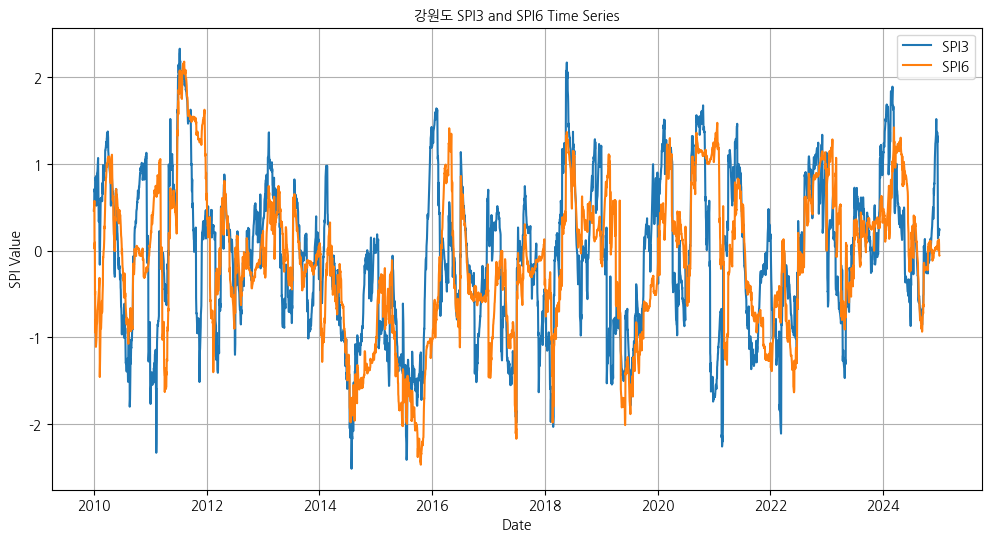

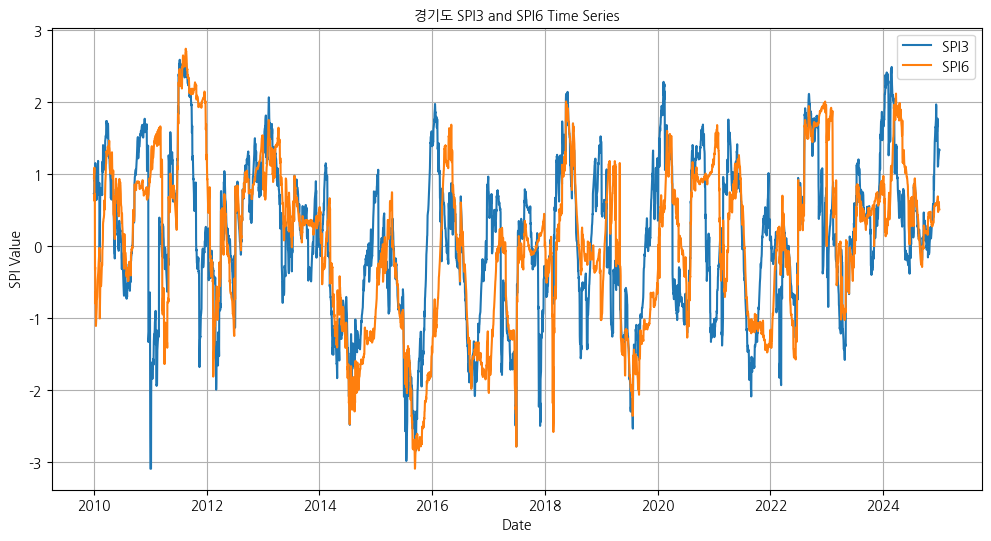

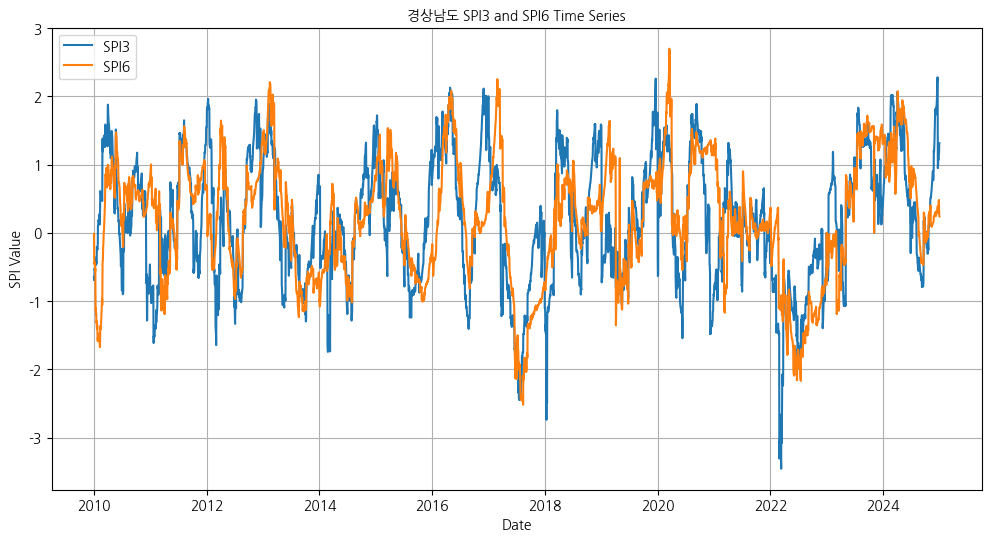

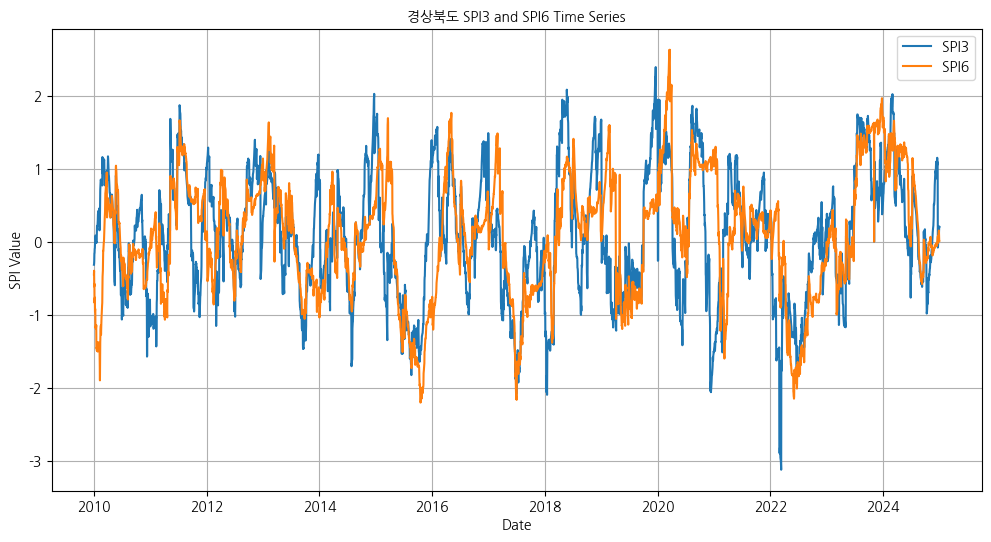

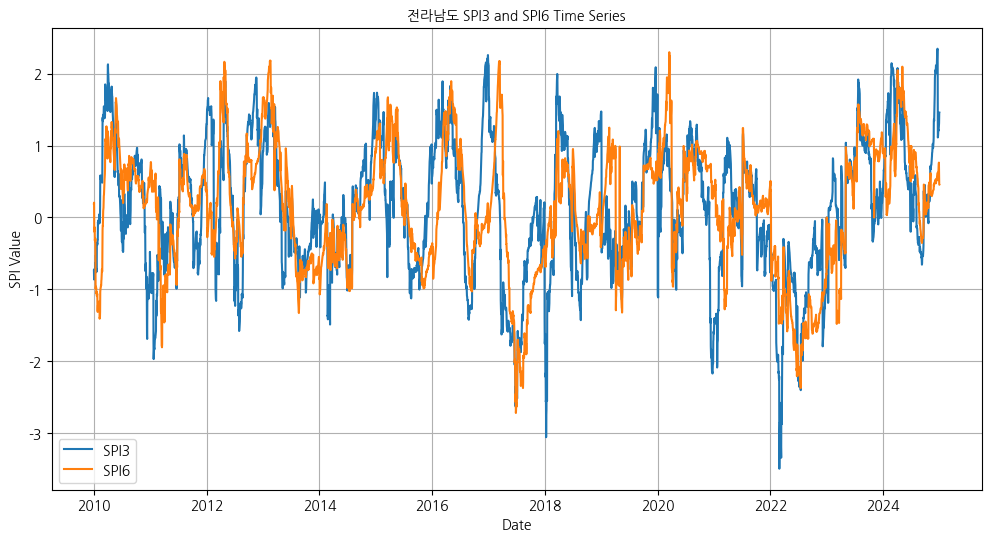

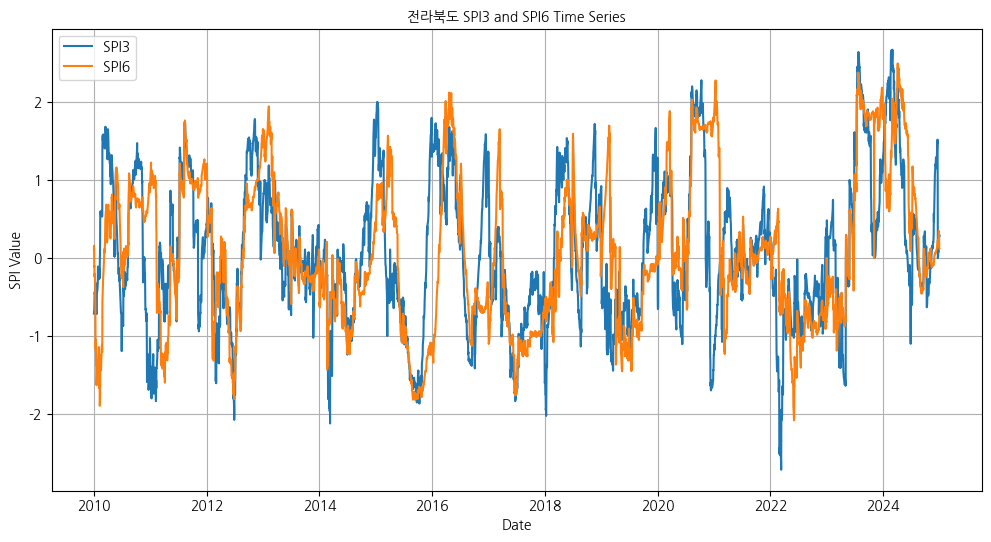

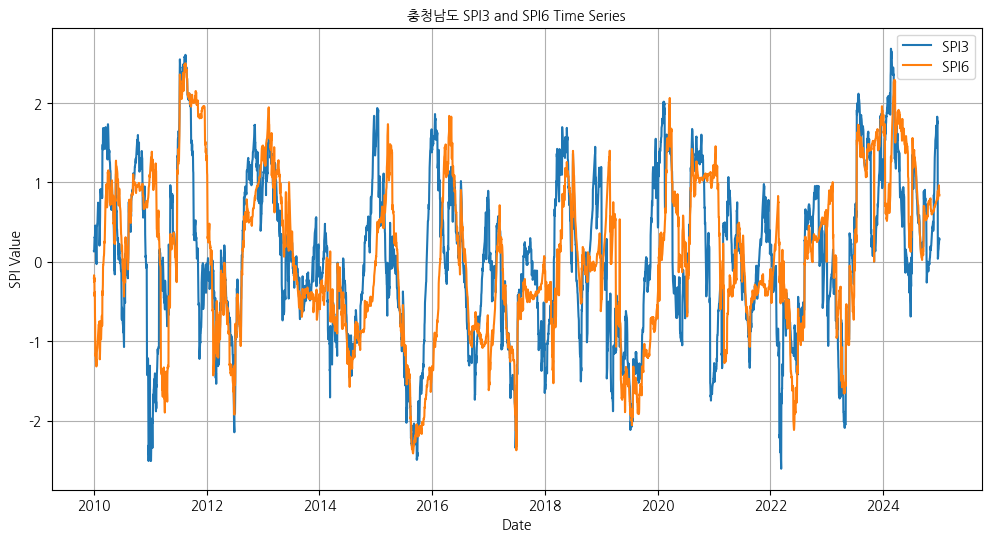

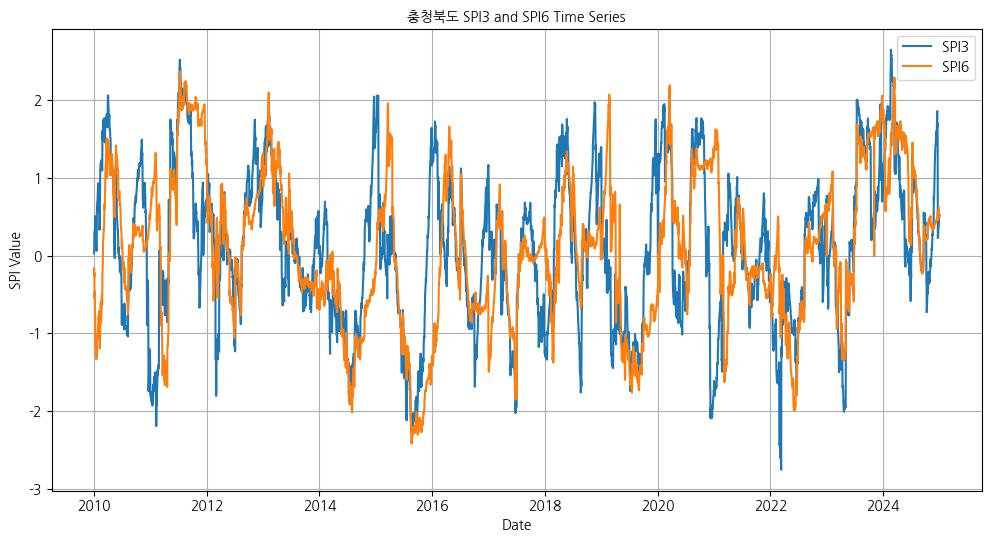

In [19]:
# '일시' 컬럼을 datetime 객체로 변환 (필요하다면)
df_spi_avg['일시'] = pd.to_datetime(df_spi_avg['일시'])

# 각 시도별로 시계열 그래프 그리기
unique_sidos = df_spi_avg['시도명'].unique()

# 나눔고딕 폰트 경로 확인 및 설정
font_path = fm.findfont(fm.FontProperties(family='NanumGothic'))
print(f"나눔고딕 폰트 경로: {font_path}")

# matplotlib 폰트 설정 (나눔고딕 및 마이너스 기호 지원 추가)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False # <-- 이 설정을 추가하여 마이너스 기호가 깨지는 것을 방지합니다.


for sido in unique_sidos:
    df_sido = df_spi_avg[df_spi_avg['시도명'] == sido].copy()

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_sido, x='일시', y='SPI3', label='SPI3')
    sns.lineplot(data=df_sido, x='일시', y='SPI6', label='SPI6')

    # 그래프 제목에 폰트 명시적으로 지정 (필요시) - 전역 설정으로 충분할 수 있습니다.
    plt.title(f'{sido} SPI3 and SPI6 Time Series', fontproperties=fm.FontProperties(fname=font_path))
    plt.xlabel('Date')
    plt.ylabel('SPI Value')
    plt.legend()
    plt.grid(True)
    plt.show()

# 가뭄일수 일정수준 이하인 날

In [20]:
# '일시' 컬럼에서 연도 추출
df_spi_avg['연도'] = pd.to_datetime(df_spi_avg['일시']).dt.year

# 모든 시도와 2010년부터 2024년까지의 모든 연도 조합 생성
all_sidos = df_spi_avg['시도명'].unique()
all_years = range(2010, 2025) # 2010년부터 2024년까지

# 모든 시도-연도 조합 데이터프레임 생성
from itertools import product
all_combinations = list(product(all_sidos, all_years))
df_all_combinations = pd.DataFrame(all_combinations, columns=['시도명', '연도'])


# 각 시도별, 연도별 SPI3이 -1.5 이하인 일수 계산
spi3_low_count_yearly = df_spi_avg[df_spi_avg['SPI3'] <= -1.5].groupby(['시도명', '연도']).size().reset_index(name='SPI3_low_days')

# 각 시도별, 연도별 SPI6이 -1.5 이하인 일수 계산
spi6_low_count_yearly = df_spi_avg[df_spi_avg['SPI6'] <= -1.5].groupby(['시도명', '연도']).size().reset_index(name='SPI6_low_days')

# 전체 시도-연도 조합 데이터프레임에 SPI 저값 일수 데이터 병합 (left join 사용)
# 이렇게 하면 모든 조합이 유지되고, 해당 데이터가 없는 경우 NaN이 됩니다.
df_spi_low_days_yearly = pd.merge(df_all_combinations, spi3_low_count_yearly, on=['시도명', '연도'], how='left')
df_spi_low_days_yearly = pd.merge(df_spi_low_days_yearly, spi6_low_count_yearly, on=['시도명', '연도'], how='left')


# NaN 값을 0으로 채우기 (저값 일수가 없는 경우는 0일이므로)
df_spi_low_days_yearly = df_spi_low_days_yearly.fillna(0)

# 결과 데이터프레임 확인
print("각 시도별, 연도별 SPI3 및 SPI6이 -1.5 이하인 일수 (없는 연도는 0으로 채워짐):")
display(df_spi_low_days_yearly.head())

print("\ndf_spi_low_days_yearly 데이터프레임 정보:")
df_spi_low_days_yearly.info()

각 시도별, 연도별 SPI3 및 SPI6이 -1.5 이하인 일수 (없는 연도는 0으로 채워짐):


,시도명,연도,SPI3_low_days,SPI6_low_days
0,강원도,2010,5.0,0.0
1,강원도,2011,15.0,6.0
2,강원도,2012,0.0,0.0
3,강원도,2013,0.0,0.0
4,강원도,2014,40.0,74.0



df_spi_low_days_yearly 데이터프레임 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   시도명            120 non-null    object 
 1   연도             120 non-null    int64  
 2   SPI3_low_days  120 non-null    float64
 3   SPI6_low_days  120 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.9+ KB


# 폭염일수

In [21]:
# CSV 파일 경로 설정
heatwave_file_path = directory_path + 'climate_heatwave.csv'

# CSV 파일 불러오기
df_heatwave = pd.read_csv(heatwave_file_path, encoding='utf-8')

print("생성된 df_heatwave 데이터프레임의 처음 5개 행:")
display(df_heatwave.head())

print("\n생성된 df_heatwave 데이터프레임의 정보:")
df_heatwave.info()

생성된 df_heatwave 데이터프레임의 처음 5개 행:


,연도,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월,연합계,순위,지역
0,2010,0,0,0,0.0,0.0,0.2,0.8,4.3,0.3,0,0,0,5.7,13,서울경기
1,2011,0,0,0,0.0,0.0,0.2,1.3,2.3,0.2,0,0,0,4.0,14,서울경기
2,2012,0,0,0,0.0,0.0,1.7,4.0,9.0,0.0,0,0,0,14.7,5,서울경기
3,2013,0,0,0,0.0,0.0,0.0,0.0,6.7,0.0,0,0,0,6.7,11,서울경기
4,2014,0,0,0,0.0,0.7,0.0,4.8,2.0,0.0,0,0,0,7.5,10,서울경기



생성된 df_heatwave 데이터프레임의 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   연도      135 non-null    int64  
 1   1월      135 non-null    int64  
 2   2월      135 non-null    int64  
 3   3월      135 non-null    int64  
 4   4월      135 non-null    float64
 5   5월      135 non-null    float64
 6   6월      135 non-null    float64
 7   7월      135 non-null    float64
 8   8월      135 non-null    float64
 9   9월      135 non-null    float64
 10  10월     135 non-null    int64  
 11  11월     135 non-null    int64  
 12  12월     135 non-null    int64  
 13  연합계     135 non-null    float64
 14  순위      135 non-null    int64  
 15  지역      135 non-null    object 
dtypes: float64(7), int64(8), object(1)
memory usage: 17.0+ KB


In [22]:
# '순위' 컬럼 제거
df_heatwave_processed = df_heatwave.drop(columns=['순위']).copy()

# 강원영동과 강원영서 데이터 필터링
df_gangwon = df_heatwave_processed[df_heatwave_processed['지역'].isin(['강원영동', '강원영서'])].copy()

# 강원영동과 강원영서 데이터를 제외한 나머지 데이터
df_heatwave_other_regions = df_heatwave_processed[~df_heatwave_processed['지역'].isin(['강원영동', '강원영서'])].copy()

# 연도별로 그룹화하여 평균 계산 (숫자형 컬럼 중 연도 제외)
# 그룹화 기준인 '연도'는 평균 계산 대상에서 제외합니다.
cols_to_avg = [col for col in df_gangwon.select_dtypes(include=['number']).columns if col != '연도']
df_gangwon_avg = df_gangwon.groupby('연도')[cols_to_avg].mean().reset_index()


# '지역' 컬럼을 '강원도'로 설정
df_gangwon_avg['지역'] = '강원도'

# 원래 컬럼 순서대로 재배열 (합치기 전에 컬럼 순서를 맞춤)
# 나머지 데이터프레임의 컬럼 순서를 가져와서 강원 평균 데이터프레임에 적용
# '순위' 컬럼은 이미 제거되었으므로, 나머지 데이터프레임의 컬럼 순서를 따릅니다.
processed_cols_order = df_heatwave_processed.columns.tolist()
df_gangwon_avg = df_gangwon_avg[processed_cols_order]
# df_heatwave_other_regions와 df_gangwon_avg를 합치기 (위아래로 붙이기)
# 컬럼 구조가 동일하므로 concat을 사용합니다.
df_heatwave_processed = pd.concat([df_heatwave_other_regions, df_gangwon_avg], ignore_index=True)


# 지역과 시도명 매핑 딕셔너리
sido_mapping_heatwave_full = {
    '서울경기': '경기도',
    '강원도': '강원도',
    '충북': '충청북도',
    '충남': '충청남도',
    '전남': '전라남도',
    '전북': '전라북도',
    '경남': '경상남도',
    '경북': '경상북도'
}

# '지역' 컬럼을 사용하여 '시도명' 컬럼 생성 및 값 할당
df_heatwave_processed['시도명'] = df_heatwave_processed['지역'].map(sido_mapping_heatwave_full)

print("df_heatwave_processed 데이터프레임에 '시도명' 컬럼이 추가된 처음 5개 행:")
display(df_heatwave_processed.head())

print("\n'시도명' 컬럼의 고유값 확인:")
print(df_heatwave_processed['시도명'].unique())

df_heatwave_processed 데이터프레임에 '시도명' 컬럼이 추가된 처음 5개 행:


,연도,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월,연합계,지역,시도명
0,2010,0.0,0.0,0.0,0.0,0.0,0.2,0.8,4.3,0.3,0.0,0.0,0.0,5.7,서울경기,경기도
1,2011,0.0,0.0,0.0,0.0,0.0,0.2,1.3,2.3,0.2,0.0,0.0,0.0,4.0,서울경기,경기도
2,2012,0.0,0.0,0.0,0.0,0.0,1.7,4.0,9.0,0.0,0.0,0.0,0.0,14.7,서울경기,경기도
3,2013,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.7,0.0,0.0,0.0,0.0,6.7,서울경기,경기도
4,2014,0.0,0.0,0.0,0.0,0.7,0.0,4.8,2.0,0.0,0.0,0.0,0.0,7.5,서울경기,경기도



'시도명' 컬럼의 고유값 확인:
['경기도' '충청북도' '충청남도' '전라북도' '전라남도' '경상북도' '경상남도' '강원도']


--- Area 데이터 시계열 그래프 ---


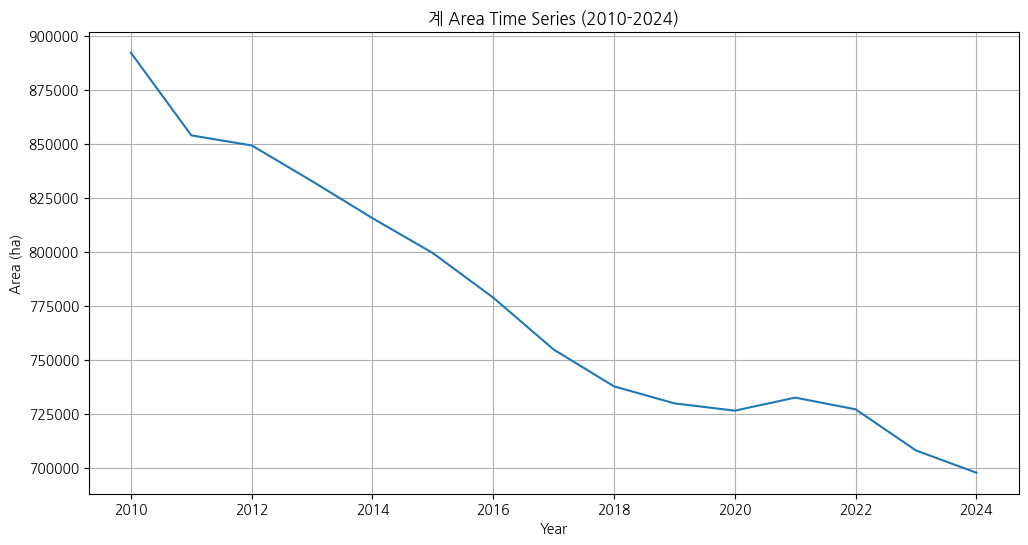

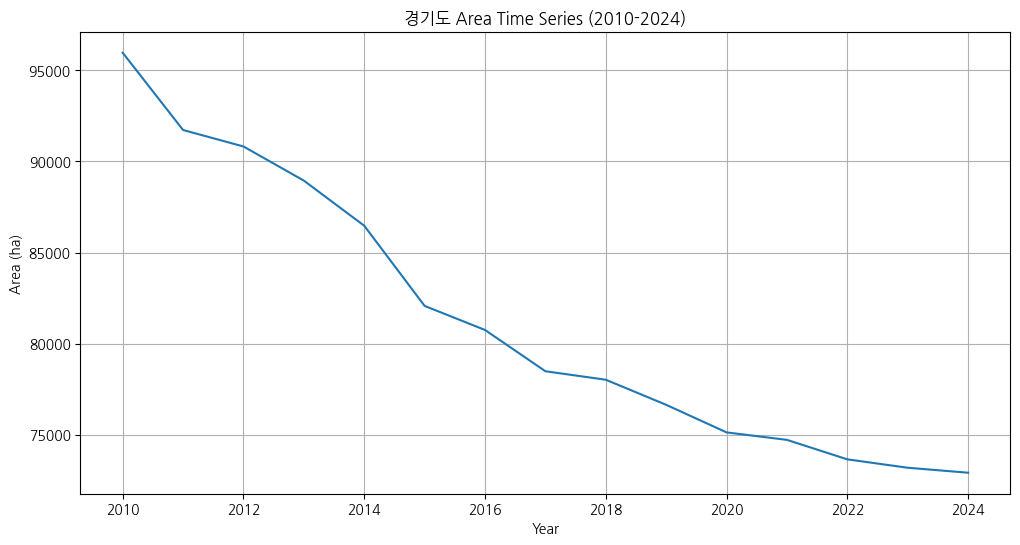

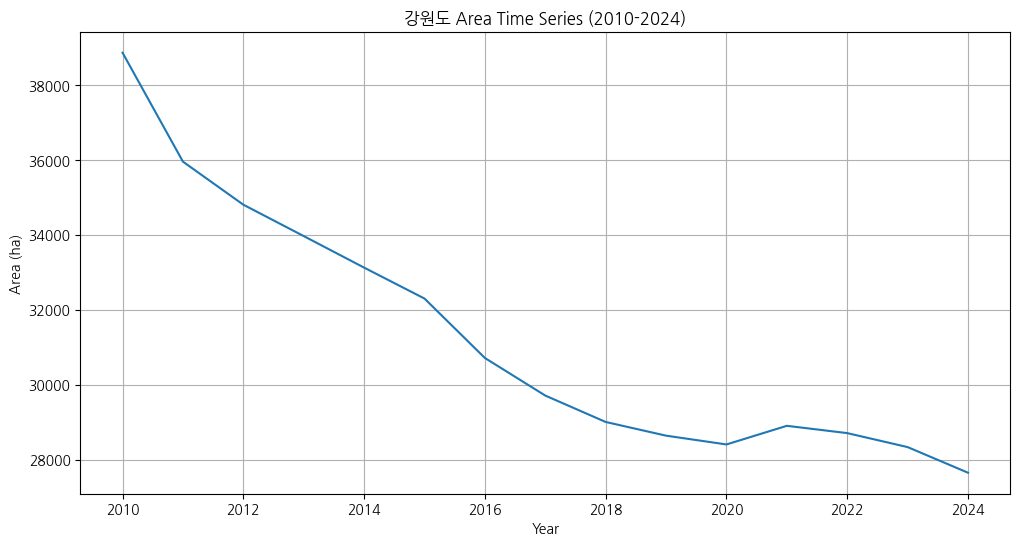

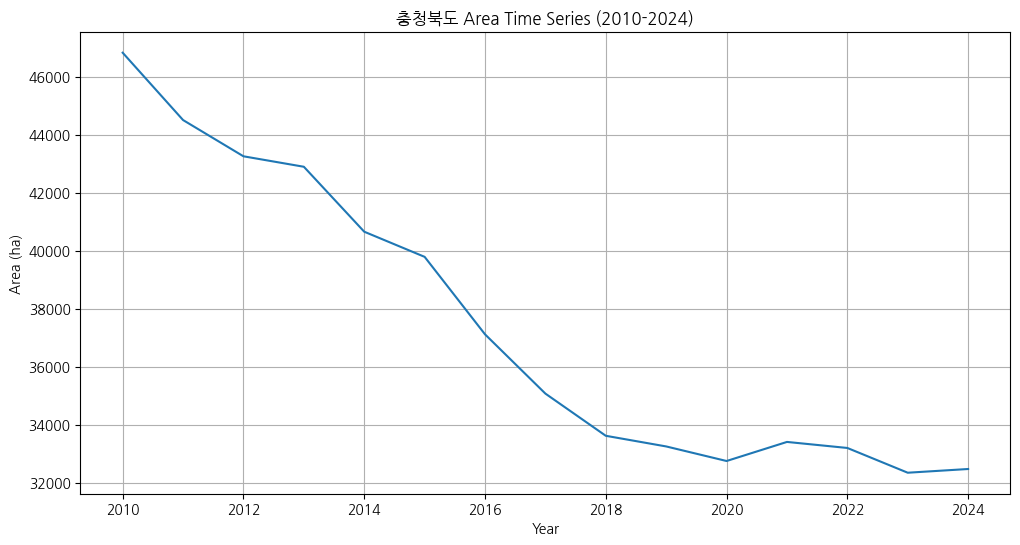

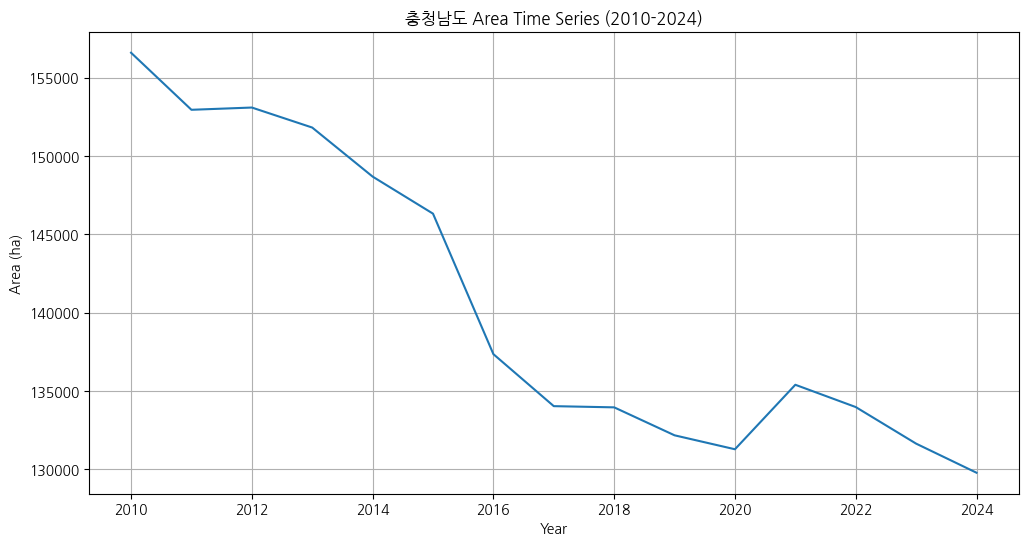

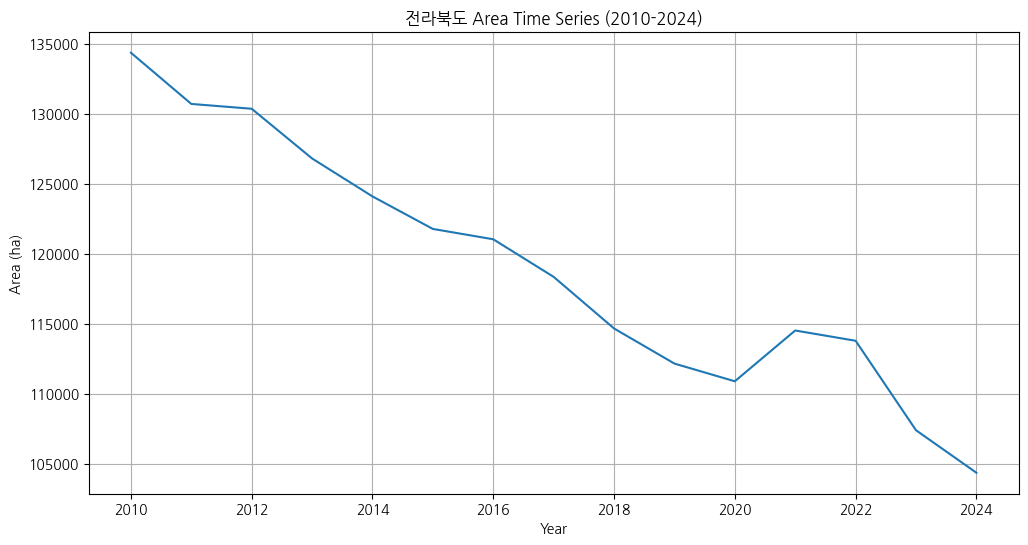

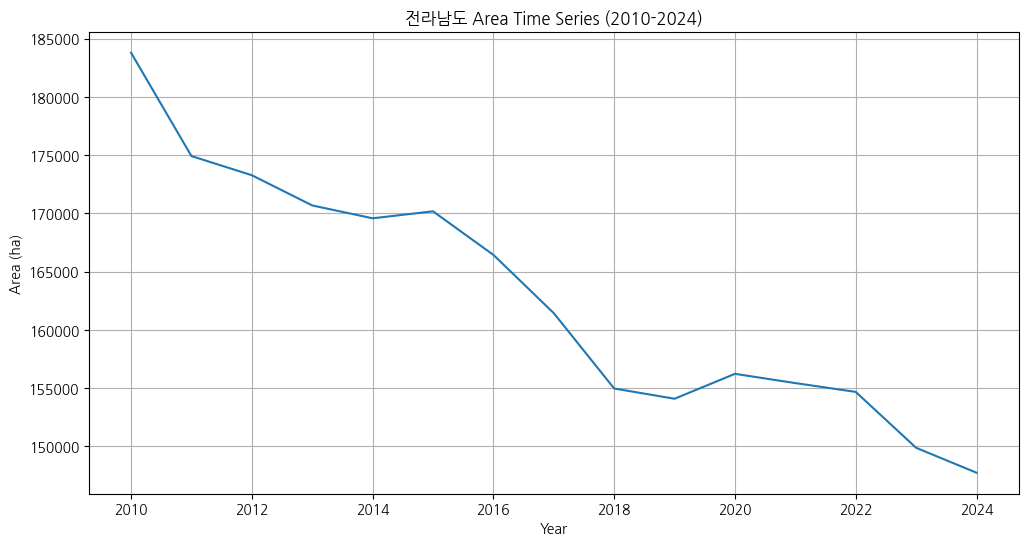

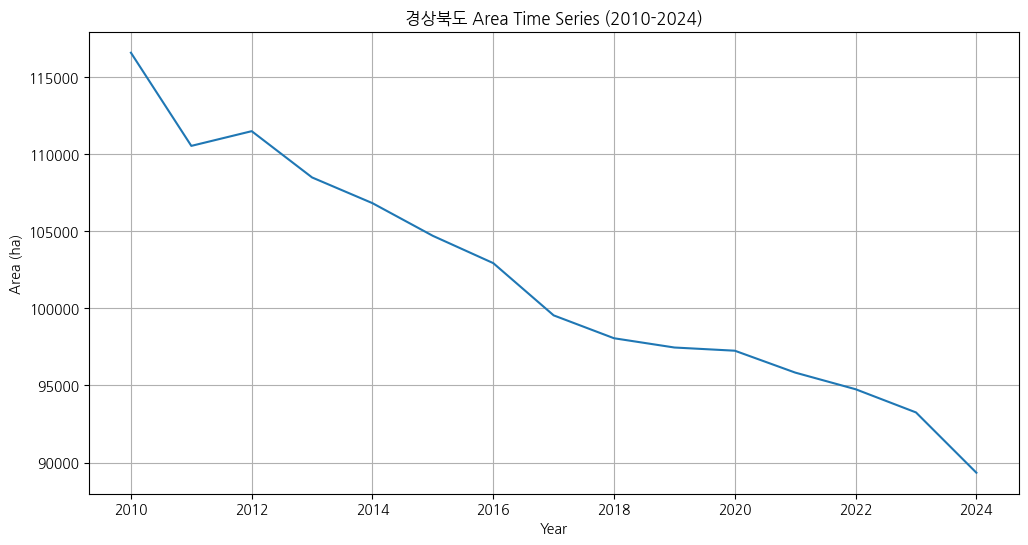

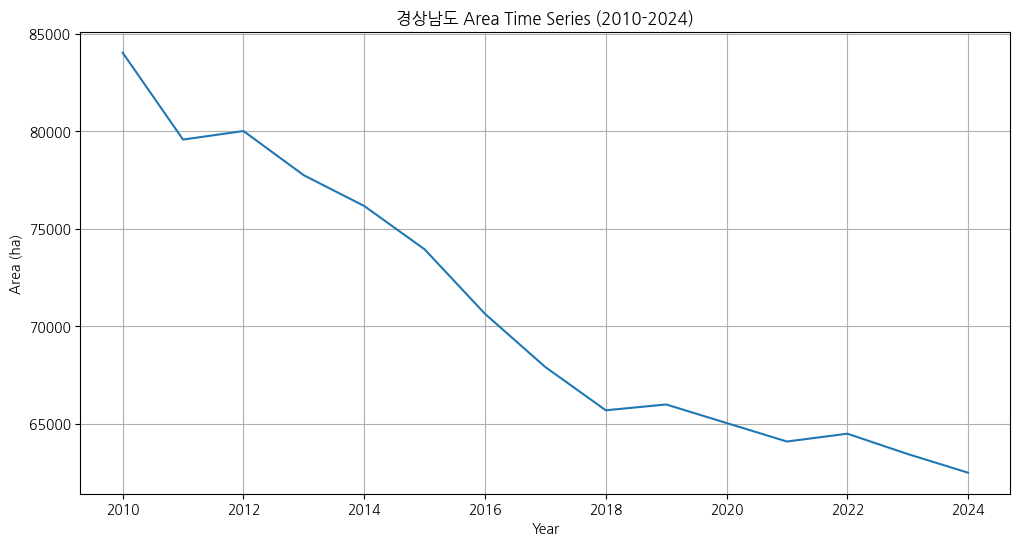

--- Area Production 데이터 시계열 그래프 ---


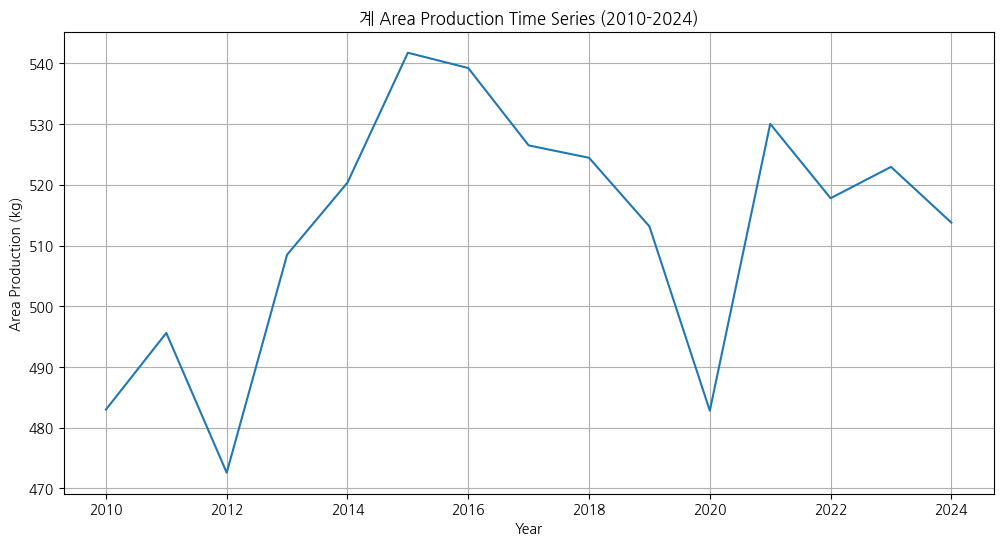

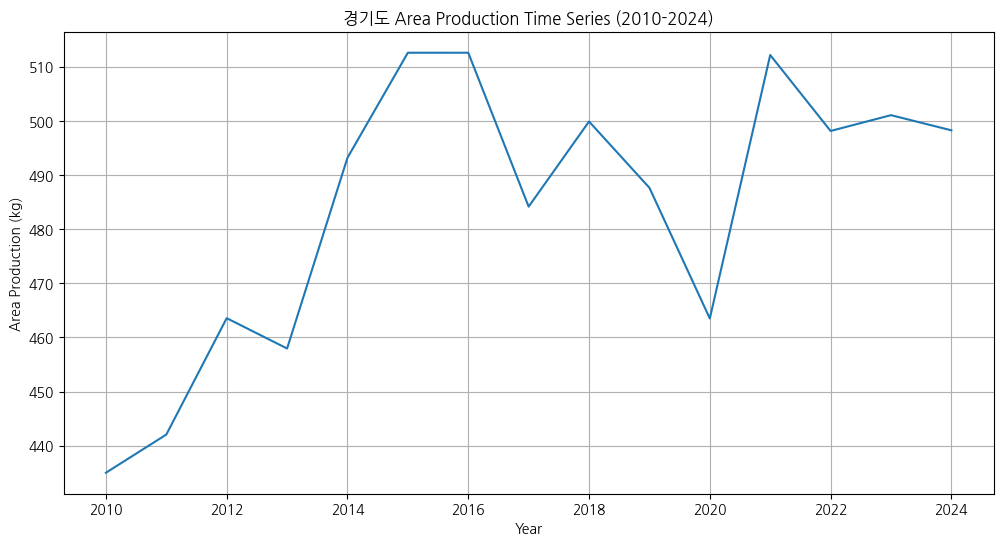

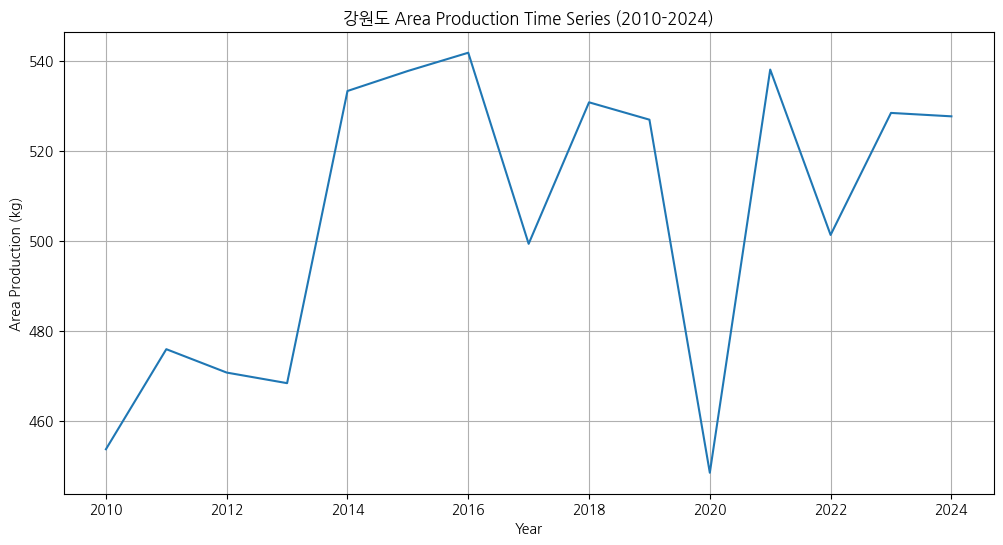

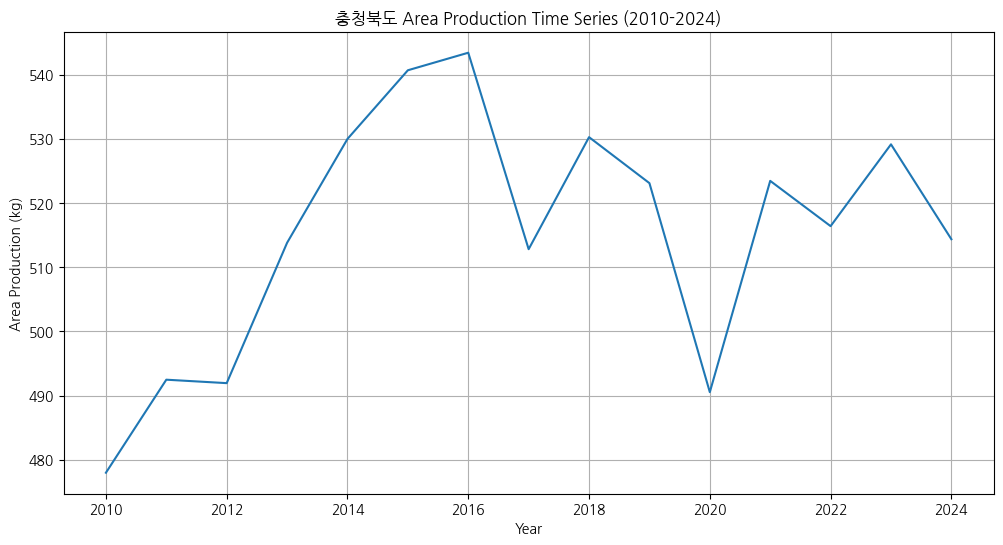

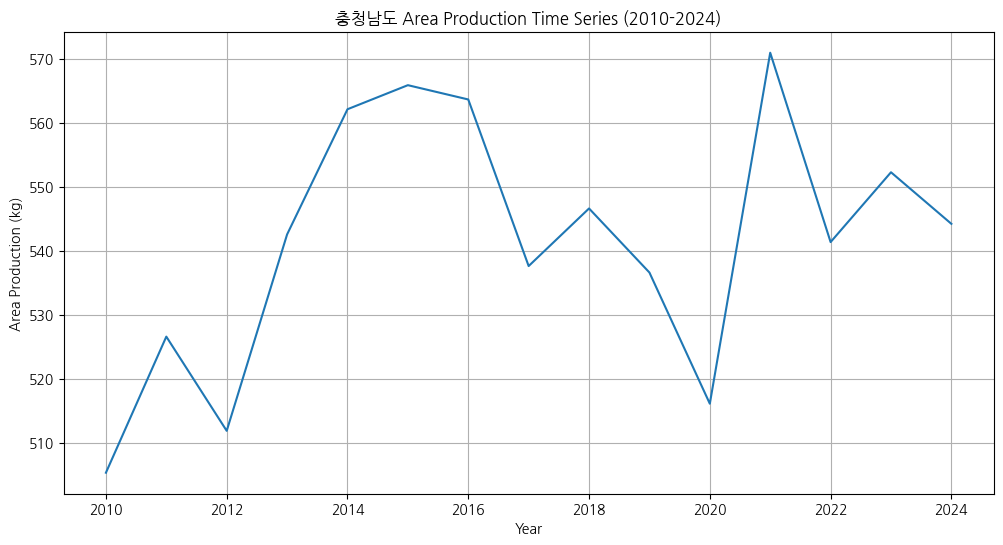

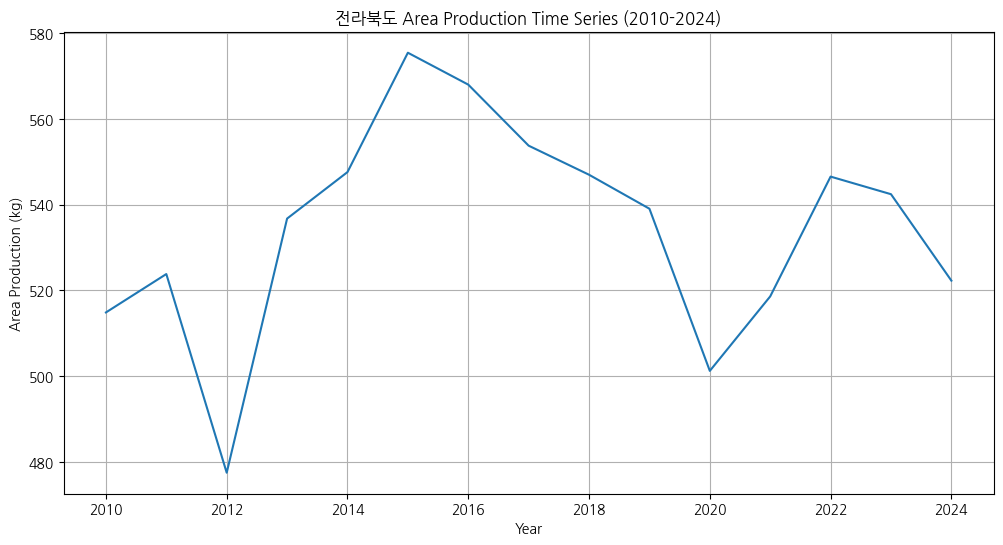

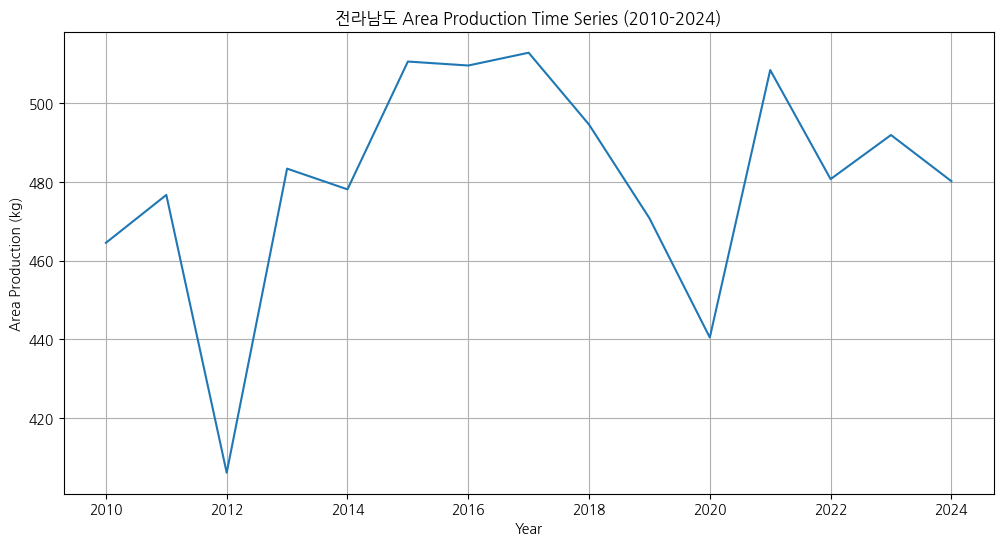

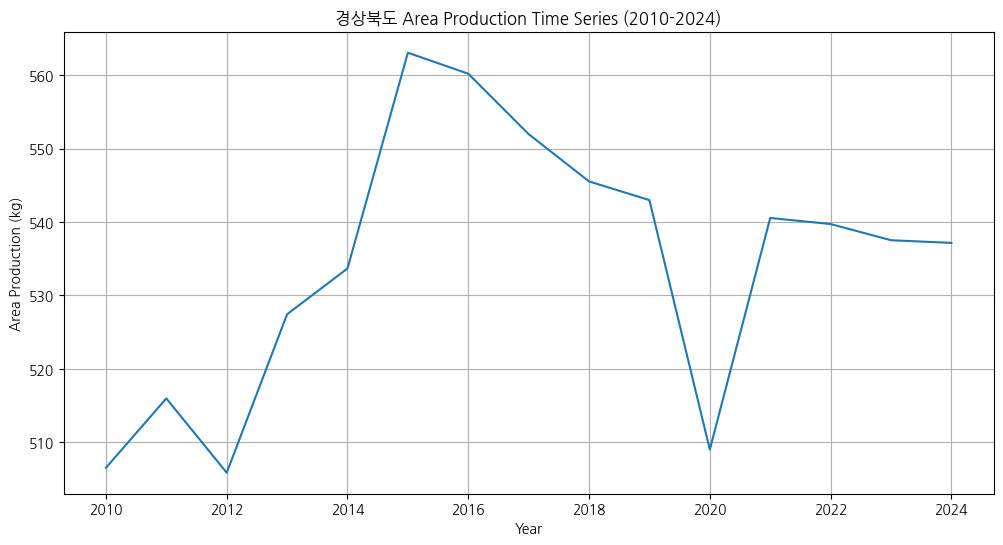

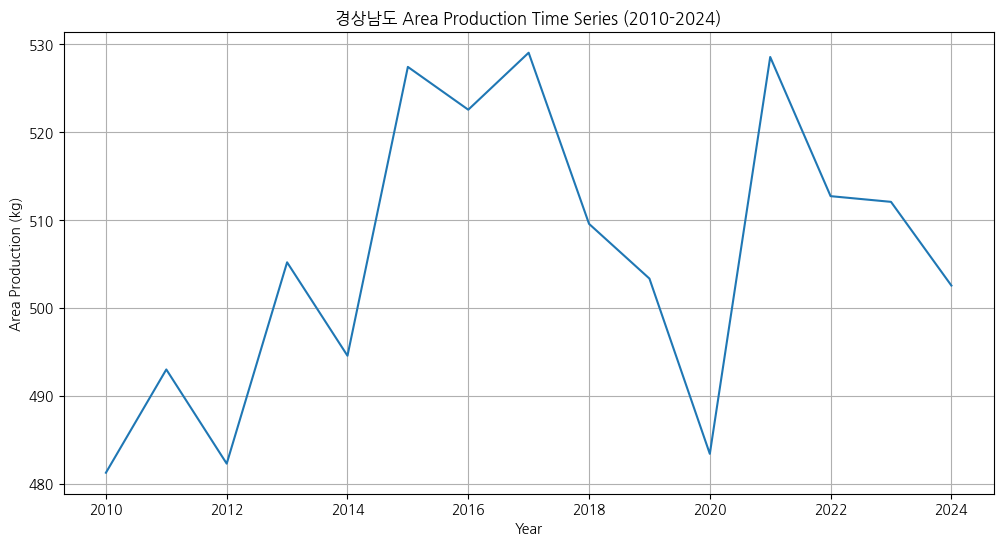

--- Production 데이터 시계열 그래프 ---


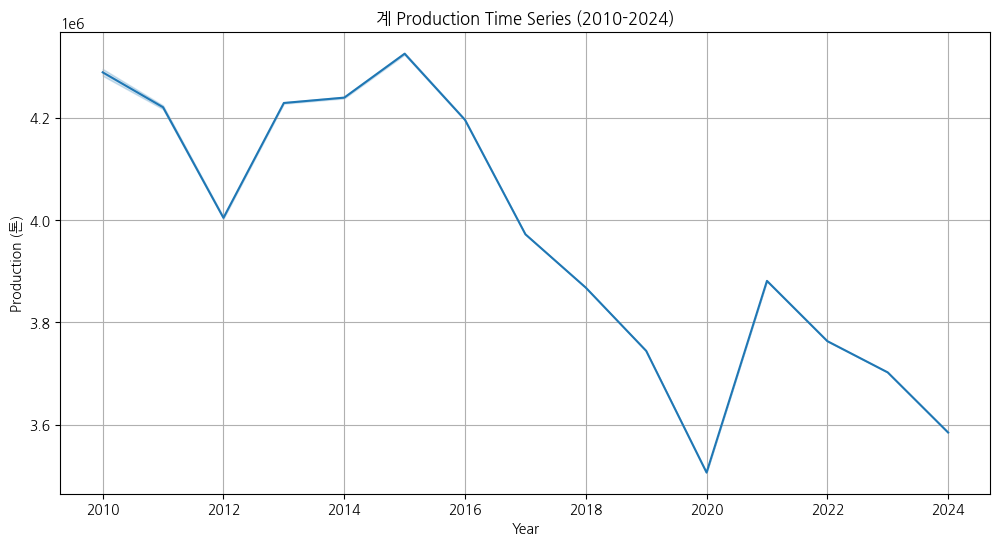

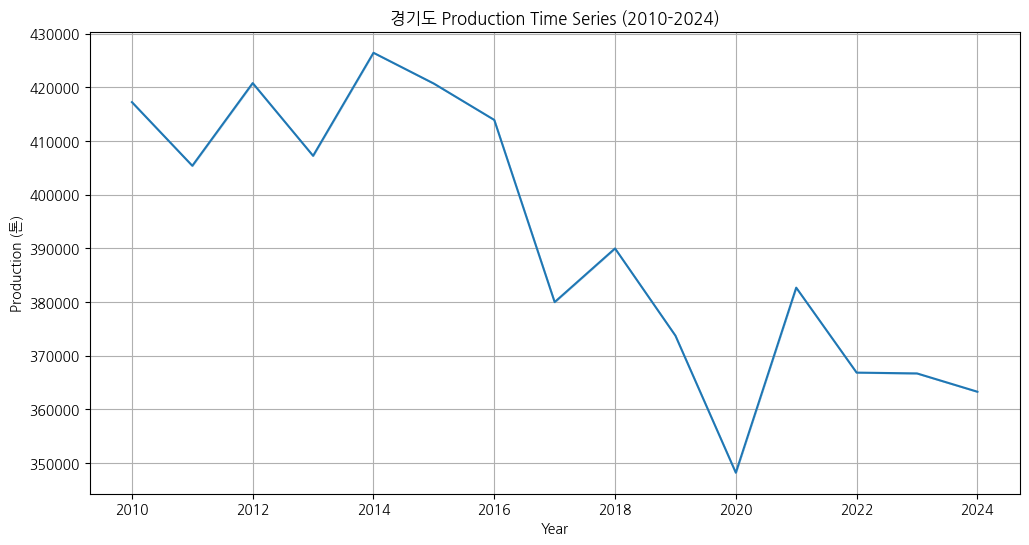

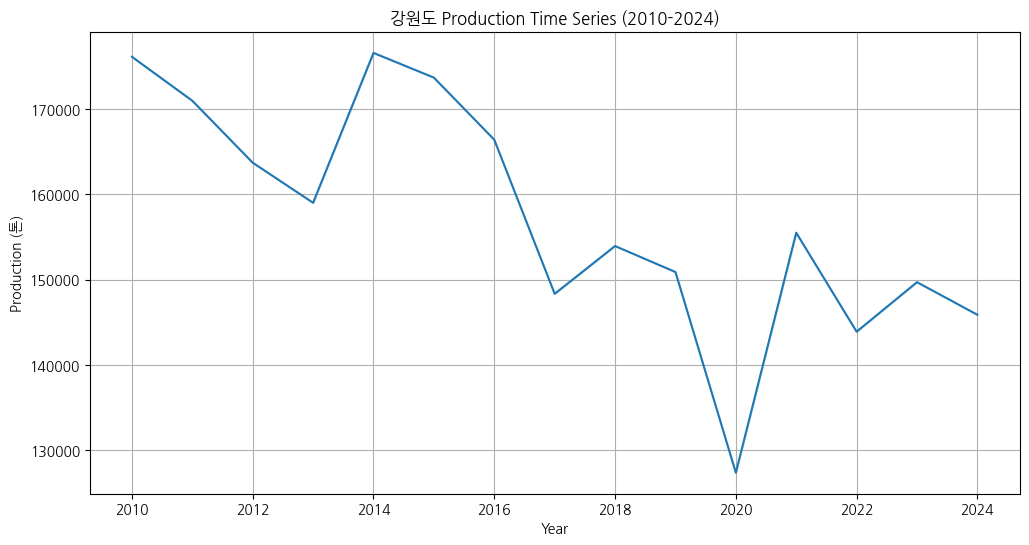

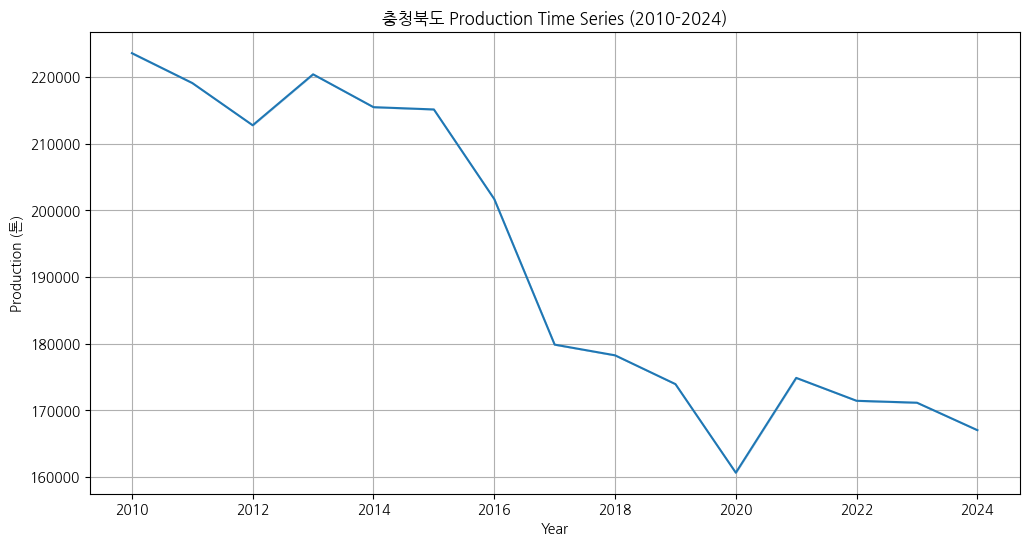

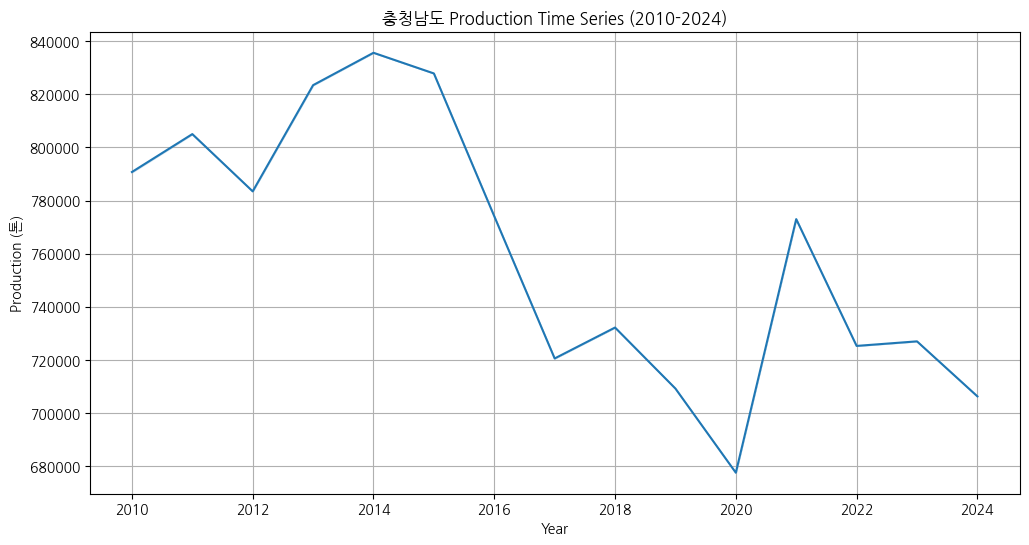

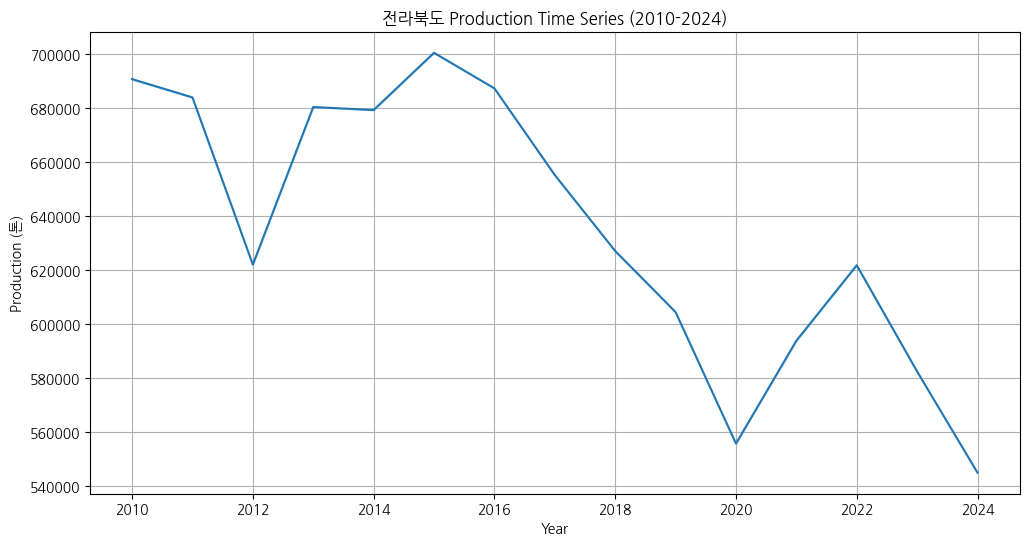

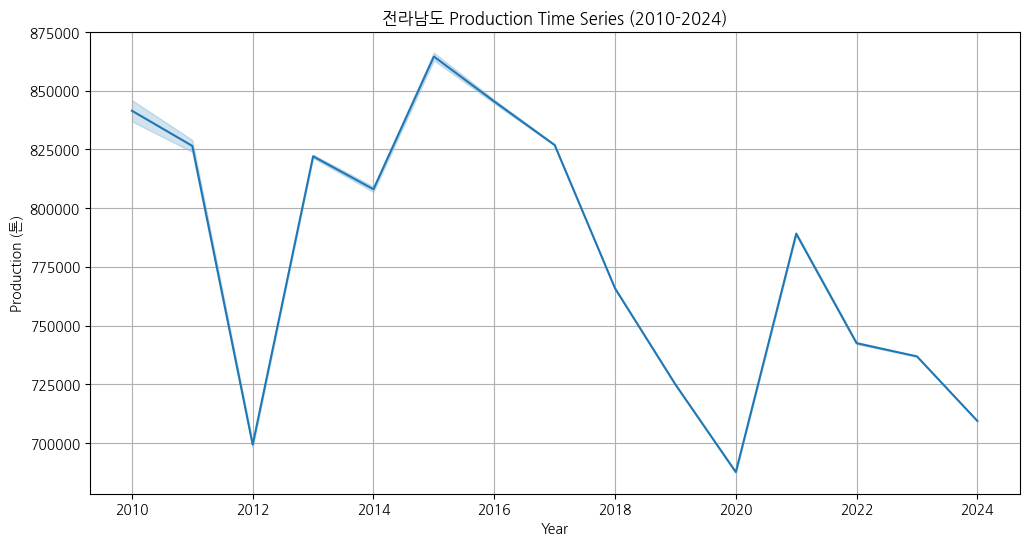

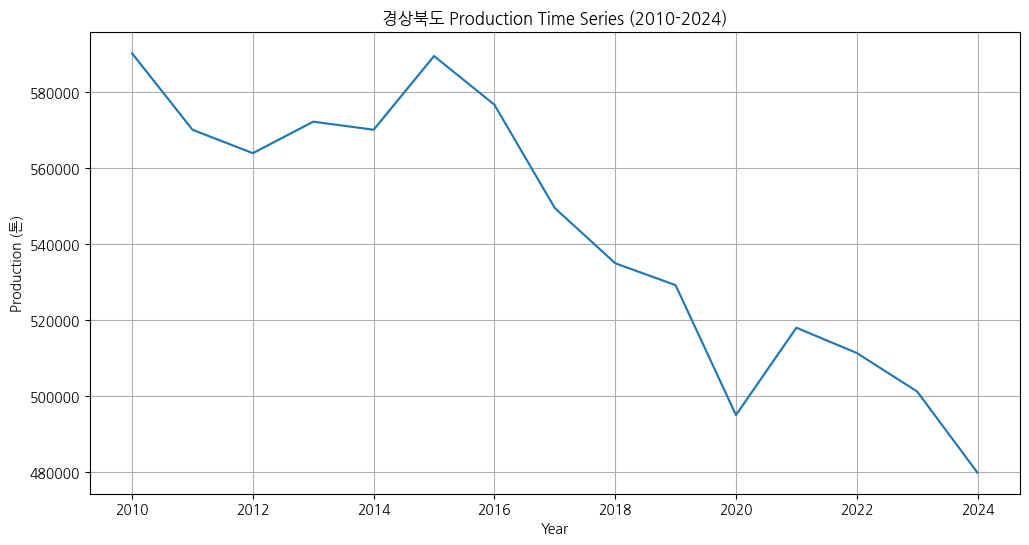

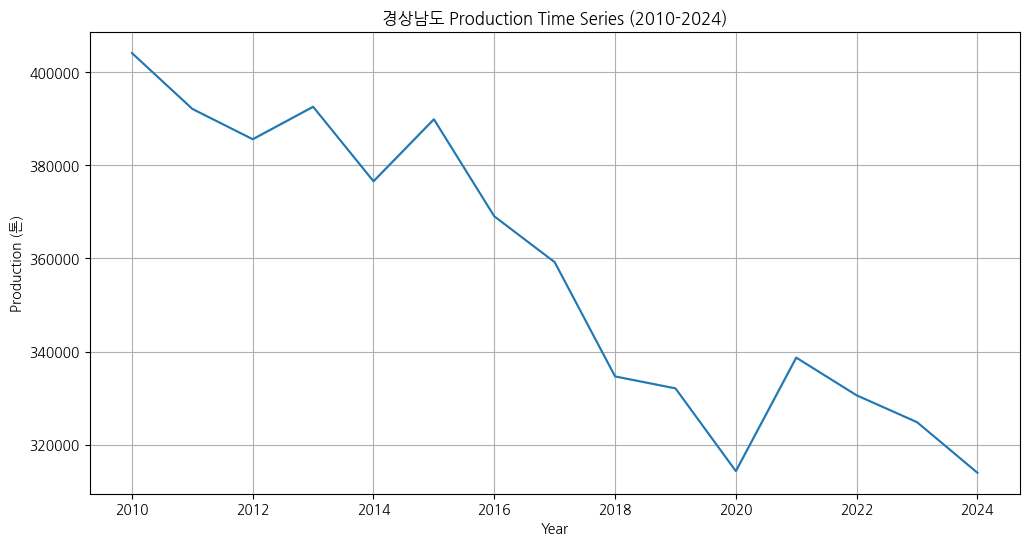

In [23]:
# 시계열 그래프를 그릴 데이터프레임 목록
dataframes_to_plot = {
    'Area': df_rice_area,
    'Area Production': df_rice_area_production,
    'Production': df_rice_production
}

# 각 데이터프레임별로 시계열 그래프 그리기
for df_name, df in dataframes_to_plot.items():
    print(f"--- {df_name} 데이터 시계열 그래프 ---")

    # 'PRD_DE' 컬럼을 숫자로 변환 (연도)
    df['PRD_DE'] = pd.to_numeric(df['PRD_DE'])
    # 'DT' 컬럼을 숫자로 변환 (값)
    df['DT'] = pd.to_numeric(df['DT'])


    unique_c1_nms = df['C1_NM'].unique()

    for c1_nm in unique_c1_nms:
        df_c1_nm = df[df['C1_NM'] == c1_nm].copy()

        plt.figure(figsize=(12, 6))
        sns.lineplot(data=df_c1_nm, x='PRD_DE', y='DT')
        plt.title(f'{c1_nm} {df_name} Time Series (2010-2024)')
        plt.xlabel('Year')
        plt.ylabel(f'{df_name} ({df["UNIT_NM"].iloc[0]})') # 단위는 첫 번째 값 사용
        plt.grid(True)
        plt.show()

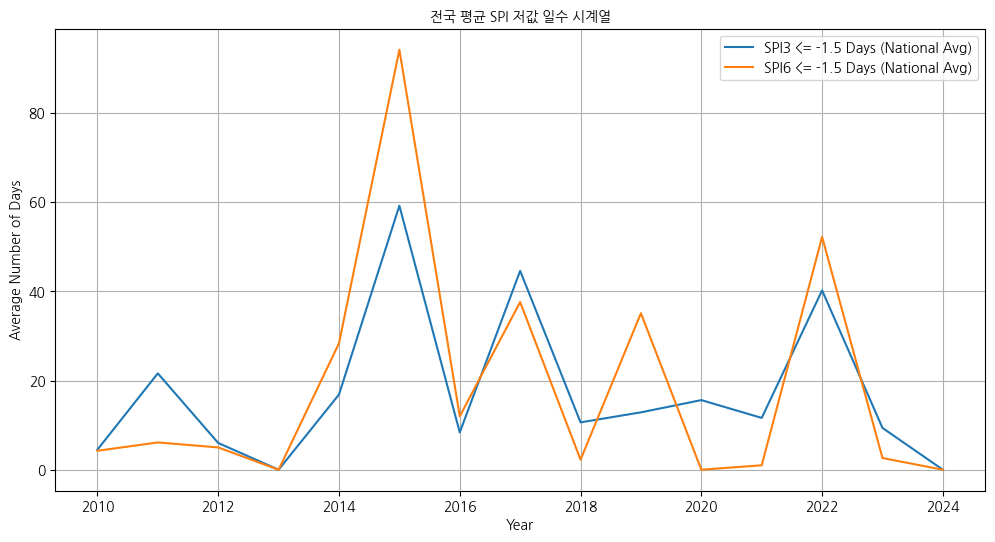

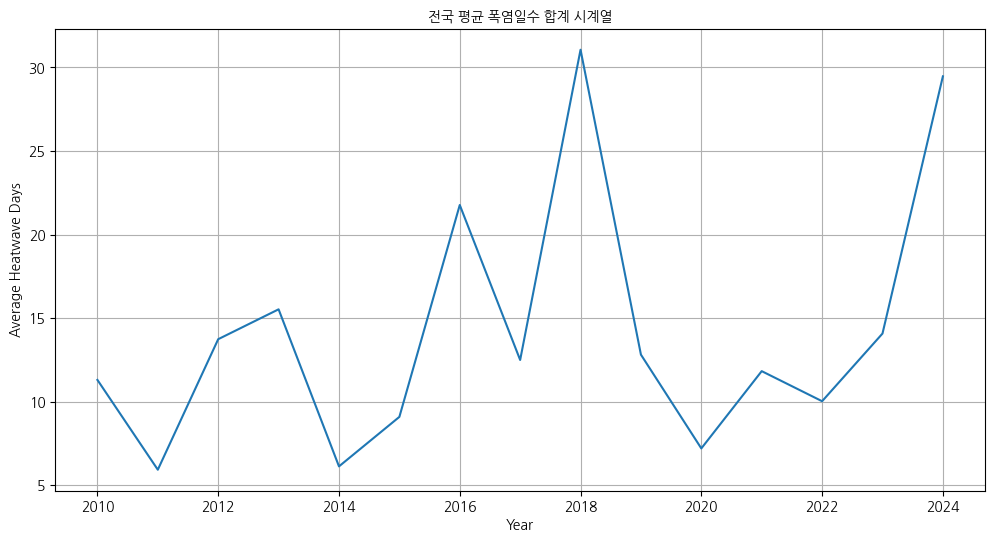

In [24]:
# df_heatwave_processed의 '연합계' 컬럼 이름을 변경
df_heatwave_processed_renamed = df_heatwave_processed.rename(columns={'연합계': '폭염일수_합계'})

# SPI 데이터 전국 평균 계산
# '일시' 컬럼을 연도별로 변환하거나, 이미 연도별로 집계된 df_spi_low_days_yearly 사용
# SPI 저값 일수 데이터를 사용하므로, df_spi_low_days_yearly에서 연도별 평균을 계산합니다.
df_spi_low_days_national_avg = df_spi_low_days_yearly.groupby('연도')[['SPI3_low_days', 'SPI6_low_days']].mean().reset_index()

# 폭염일수 데이터 전국 평균 계산
# df_heatwave_processed 데이터프레임에서 연도별 '폭염일수_합계' 평균을 계산합니다.
df_heatwave_national_avg = df_heatwave_processed_renamed.groupby('연도')['폭염일수_합계'].mean().reset_index()


# 전국 평균 SPI 저값 일수 시계열 그래프
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_spi_low_days_national_avg, x='연도', y='SPI3_low_days', label='SPI3 <= -1.5 Days (National Avg)')
sns.lineplot(data=df_spi_low_days_national_avg, x='연도', y='SPI6_low_days', label='SPI6 <= -1.5 Days (National Avg)')

# 한글 타이틀 설정
try:
    font_path = fm.findfont(fm.FontProperties(family='NanumGothic'))
    plt.rc('font', family='NanumGothic')
    plt.rcParams['axes.unicode_minus'] = False
    plt.title('전국 평균 SPI 저값 일수 시계열', fontproperties=fm.FontProperties(fname=font_path))
except:
    plt.title('National Average SPI Low Days Time Series')
    print("나눔고딕 폰트 경로를 찾을 수 없어 기본 폰트로 표시합니다.")

plt.xlabel('Year')
plt.ylabel('Average Number of Days')
plt.legend()
plt.grid(True)
plt.show()

# 전국 평균 폭염일수 합계 시계열 그래프
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_heatwave_national_avg, x='연도', y='폭염일수_합계')

# 한글 타이틀 설정
try:
    font_path = fm.findfont(fm.FontProperties(family='NanumGothic'))
    plt.rc('font', family='NanumGothic')
    plt.rcParams['axes.unicode_minus'] = False
    plt.title('전국 평균 폭염일수 합계 시계열', fontproperties=fm.FontProperties(fname=font_path))
except:
    plt.title('National Average Heatwave Days Time Series')
    print("나눔고딕 폰트 경로를 찾을 수 없어 기본 폰트로 표시합니다.")

plt.xlabel('Year')
plt.ylabel('Average Heatwave Days')
plt.grid(True)
plt.show()

In [25]:
df_spi_low_days_yearly.head(120)

,시도명,연도,SPI3_low_days,SPI6_low_days
0,강원도,2010,5.0,0.0
1,강원도,2011,15.0,6.0
2,강원도,2012,0.0,0.0
3,강원도,2013,0.0,0.0
4,강원도,2014,40.0,74.0
...,...,...,...,...
115,충청북도,2020,25.0,0.0
116,충청북도,2021,20.0,3.0
117,충청북도,2022,30.0,38.0
118,충청북도,2023,22.0,0.0


In [26]:
df_heatwave_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   연도      120 non-null    int64  
 1   1월      120 non-null    float64
 2   2월      120 non-null    float64
 3   3월      120 non-null    float64
 4   4월      120 non-null    float64
 5   5월      120 non-null    float64
 6   6월      120 non-null    float64
 7   7월      120 non-null    float64
 8   8월      120 non-null    float64
 9   9월      120 non-null    float64
 10  10월     120 non-null    float64
 11  11월     120 non-null    float64
 12  12월     120 non-null    float64
 13  연합계     120 non-null    float64
 14  지역      120 non-null    object 
 15  시도명     120 non-null    object 
dtypes: float64(13), int64(1), object(2)
memory usage: 15.1+ KB


# 합체된 데이터프레임

In [27]:
# 1. '합계:생산량' 데이터만 선택하여 연도와 시도별로 그룹화 및 합계 계산
df_total_production = df_rice_production[df_rice_production['ITM_NM'] == '합계:생산량'].groupby(['PRD_DE', 'C1_NM'])['DT'].sum().reset_index()
df_total_production.columns = ['연도', '시도명', '총_생산량']

# 2. '논벼:10a당 생산량' 데이터를 연도와 시도별로 그룹화 및 평균 계산
df_avg_area_production = df_rice_area_production.groupby(['PRD_DE', 'C1_NM'])['DT'].mean().reset_index()
df_avg_area_production.columns = ['연도', '시도명', '면적당_생산량']

# 3. '합계:면적' 데이터를 연도와 시도별로 그룹화 및 합계 계산
df_total_area = df_rice_area.groupby(['PRD_DE', 'C1_NM'])['DT'].sum().reset_index()
df_total_area.columns = ['연도', '시도명', '총_재배면적']

# '연도' 컬럼의 데이터 타입을 int로 변환 (병합을 위해)
df_total_production['연도'] = df_total_production['연도'].astype(int)
df_avg_area_production['연도'] = df_avg_area_production['연도'].astype(int)
df_total_area['연도'] = df_total_area['연도'].astype(int)

# 4. 쌀 관련 데이터프레임들을 '연도'와 '시도명' 기준으로 병합
df_rice_summary = pd.merge(df_total_production, df_avg_area_production, on=['연도', '시도명'], how='inner')
df_rice_summary = pd.merge(df_rice_summary, df_total_area, on=['연도', '시도명'], how='inner')

# 5. 기후 관련 데이터프레임들을 '연도'와 '시도명' 기준으로 병합
# df_heatwave_processed의 '연합계' 컬럼 이름을 변경
df_heatwave_processed_renamed = df_heatwave_processed.rename(columns={'연합계': '폭염일수_합계'})

# '시도명' 컬럼의 데이터 타입을 object로 변환 (병합을 위해)
df_heatwave_processed_renamed['시도명'] = df_heatwave_processed_renamed['시도명'].astype(str)
df_spi_low_days_yearly['시도명'] = df_spi_low_days_yearly['시도명'].astype(str)


df_climate_summary = pd.merge(df_spi_low_days_yearly, df_heatwave_processed_renamed[['연도', '시도명', '폭염일수_합계']], on=['연도', '시도명'], how='inner')


# 6. 쌀 데이터 요약과 기후 데이터 요약을 '연도'와 '시도명' 기준으로 병합
df_merged = pd.merge(df_rice_summary, df_climate_summary, on=['연도', '시도명'], how='inner')
df_merged = pd.merge(df_merged, wide_df, on=['연도', '시도명'], how='inner')

# 7. 최종 통합 데이터프레임 확인
print("통합된 df_merged 데이터프레임의 처음 5개 행:")
display(df_merged.head())

print("\n통합된 df_merged 데이터프레임의 정보:")
df_merged.info()

통합된 df_merged 데이터프레임의 처음 5개 행:


,연도,시도명,총_생산량,면적당_생산량,총_재배면적,SPI3_low_days,SPI6_low_days,폭염일수_합계,4_5_강수량,4_5_최고기온,...,8_평균증기압,8_평균지면온도,8_합계일사량,9_10_강수량,9_10_최고기온,9_10_최저기온,9_10_평균기온,9_10_평균증기압,9_10_평균지면온도,9_10_합계일사량
0,2010,강원도,176155.99180,453.68212,38863.0,5.0,0.0,9.0,9.798701,21.496721,...,25.731256,27.488270,12.752581,29.420513,24.250820,7.386885,15.926093,14.482787,18.191667,12.307770
1,2010,경기도,417292.60934,435.01798,95970.0,1.0,0.0,5.7,8.669474,20.578689,...,28.267258,28.626774,13.212903,32.586667,24.042623,10.942623,16.883934,15.734754,19.031148,12.881639
2,2010,경상남도,404127.72499,481.23109,84017.0,0.0,15.0,14.9,19.634921,21.567213,...,29.511828,29.964875,15.848452,26.142735,26.944262,11.852459,19.426047,17.090528,21.429690,14.161344
3,2010,경상북도,590301.31853,506.54747,116596.0,2.0,6.0,21.6,13.114685,21.924590,...,27.475978,29.561217,15.995699,15.477244,25.404918,9.085246,17.246543,15.921133,19.651258,12.654344
4,2010,전라남도,846034.55331,464.54560,183804.0,2.0,0.0,5.1,17.532941,20.663934,...,30.430968,29.790000,17.386839,20.711111,26.095082,12.972131,19.318525,17.738197,21.405246,16.084066



통합된 df_merged 데이터프레임의 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 43 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   연도             120 non-null    int64  
 1   시도명            120 non-null    object 
 2   총_생산량          120 non-null    float64
 3   면적당_생산량        120 non-null    float64
 4   총_재배면적         120 non-null    float64
 5   SPI3_low_days  120 non-null    float64
 6   SPI6_low_days  120 non-null    float64
 7   폭염일수_합계        120 non-null    float64
 8   4_5_강수량        120 non-null    float64
 9   4_5_최고기온       120 non-null    float64
 10  4_5_최저기온       120 non-null    float64
 11  4_5_평균기온       120 non-null    float64
 12  4_5_평균증기압      120 non-null    float64
 13  4_5_평균지면온도     120 non-null    float64
 14  4_5_합계일사량      120 non-null    float64
 15  6_강수량          120 non-null    float64
 16  6_최고기온         120 non-null    float64
 17  6_최저기온         120 non-null

## 상관관계 분석-원본

In [28]:
# '연도' 컬럼을 제외한 숫자형 컬럼 선택
numerical_cols = df_merged.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove('연도')

# 선택된 컬럼들로 데이터프레임 필터링
df_numeric = df_merged[numerical_cols]

# 상관관계 행렬 계산
correlation_matrix = df_numeric.corr()

print("상관관계 행렬:")
display(correlation_matrix)

상관관계 행렬:


,총_생산량,면적당_생산량,총_재배면적,SPI3_low_days,SPI6_low_days,폭염일수_합계,4_5_강수량,4_5_최고기온,4_5_최저기온,4_5_평균기온,...,8_평균증기압,8_평균지면온도,8_합계일사량,9_10_강수량,9_10_최고기온,9_10_최저기온,9_10_평균기온,9_10_평균증기압,9_10_평균지면온도,9_10_합계일사량
총_생산량,1.000000,0.166469,0.986296,0.022288,-0.024329,0.008624,0.183926,-0.138736,0.352232,0.045697,...,0.405312,0.230885,0.042693,-0.106704,0.243487,0.417552,0.422987,0.362559,0.449559,0.121757
면적당_생산량,0.166469,1.000000,0.014359,0.152659,0.197630,0.313182,-0.272453,0.400167,0.031880,0.326502,...,-0.311804,0.092623,0.223620,-0.199128,0.054806,-0.005671,0.023633,0.071294,0.065391,-0.179980
총_재배면적,0.986296,0.014359,1.000000,0.000743,-0.049328,-0.032958,0.245416,-0.187750,0.356622,0.013417,...,0.455578,0.227473,0.024978,-0.076970,0.254590,0.431816,0.438570,0.364961,0.457077,0.158411
SPI3_low_days,0.022288,0.152659,0.000743,1.000000,0.861311,-0.255698,-0.307888,0.169441,0.047291,0.122472,...,-0.250503,-0.277590,-0.212612,-0.187662,-0.141461,-0.185537,-0.180688,-0.310720,-0.144363,0.022021
SPI6_low_days,-0.024329,0.197630,-0.049328,0.861311,1.000000,-0.179627,-0.319111,0.274286,0.015854,0.182848,...,-0.312038,-0.224992,-0.063546,-0.087133,0.010497,-0.154793,-0.101491,-0.249213,-0.084637,-0.080827
폭염일수_합계,0.008624,0.313182,-0.032958,-0.255698,-0.179627,1.000000,0.283479,0.312393,0.291992,0.409175,...,0.230568,0.792565,0.607588,0.120737,0.204703,0.287625,0.278784,0.367635,0.264774,-0.257248
4_5_강수량,0.183926,-0.272453,0.245416,-0.307888,-0.319111,0.283479,1.000000,0.026219,0.299542,0.207719,...,0.420227,0.453417,0.308008,0.132150,0.434202,0.378082,0.471759,0.382300,0.437939,0.118645
4_5_최고기온,-0.138736,0.400167,-0.187750,0.169441,0.274286,0.312393,0.026219,1.000000,0.153472,0.821278,...,-0.292367,0.082409,0.198940,0.287904,0.336071,-0.000828,0.172104,0.142286,0.190341,-0.269196
4_5_최저기온,0.352232,0.031880,0.356622,0.047291,0.015854,0.291992,0.299542,0.153472,1.000000,0.642112,...,0.402968,0.372902,0.214689,-0.018233,0.289277,0.721406,0.598205,0.488755,0.574905,0.024529
4_5_평균기온,0.045697,0.326502,0.013417,0.122472,0.182848,0.409175,0.207719,0.821278,0.642112,1.000000,...,0.013773,0.271906,0.296281,0.221639,0.435845,0.400821,0.483871,0.396768,0.490458,-0.128587


In [29]:
# '총_생산량'과의 상관계수만 추출
corr_target = correlation_matrix['총_생산량']

# 절댓값 0.3 이상 필터링
strong_corr = corr_target[abs(corr_target) >= 0.3]

strong_corr


,총_생산량
총_생산량,1.000000
총_재배면적,0.986296
4_5_최저기온,0.352232
4_5_평균증기압,0.538910
6_최고기온,-0.401065
6_최저기온,0.382303
6_평균증기압,0.509120
7_최저기온,0.342732
7_평균증기압,0.440023
8_최저기온,0.366599


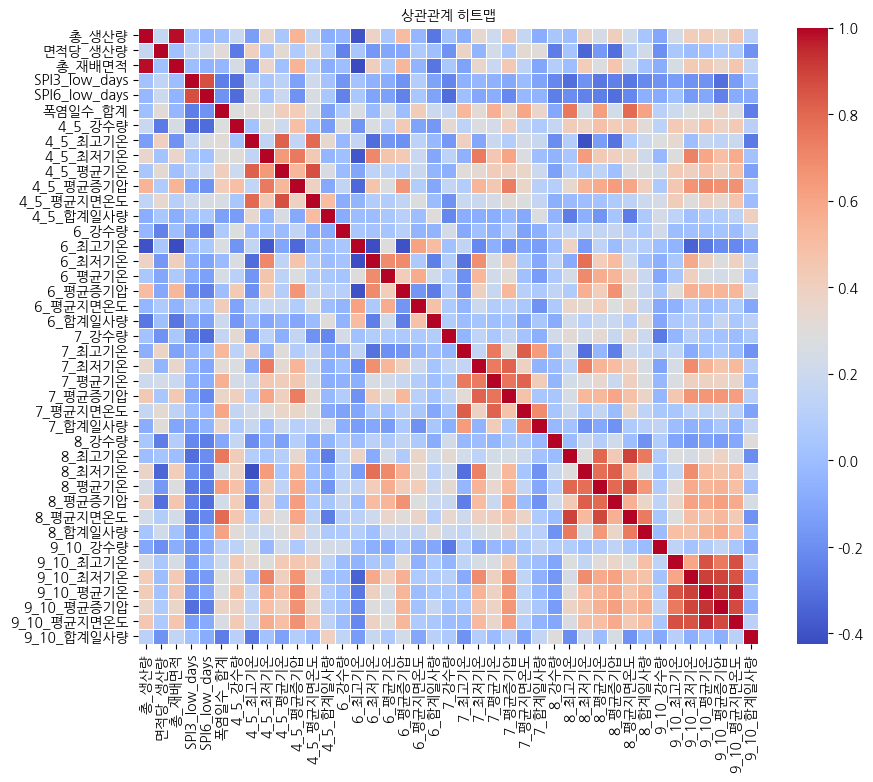

In [30]:
# 히트맵 그리기
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)

# 한글 타이틀 설정
plt.title('상관관계 히트맵', fontproperties=fm.FontProperties(fname=font_path))

# 히트맵 표시
plt.show()

# 변화량 계산해서 다시 상관관계 분석

In [31]:
# 1. 쌀 관련 데이터 준비 및 정리
# '합계:생산량' 데이터만 선택하여 연도와 시도별로 그룹화 및 합계 계산
df_total_production = df_rice_production[df_rice_production['ITM_NM'] == '합계:생산량'].groupby(['PRD_DE', 'C1_NM'])['DT'].sum().reset_index()
df_total_production.columns = ['연도', '시도명', '총_생산량']

# '논벼:10a당 생산량' 데이터를 연도와 시도별로 그룹화 및 평균 계산
df_avg_area_production = df_rice_area_production.groupby(['PRD_DE', 'C1_NM'])['DT'].mean().reset_index()
df_avg_area_production.columns = ['연도', '시도명', '면적당_생산량']

# '합계:면적' 데이터를 연도와 시도별로 그룹화 및 합계 계산
df_total_area = df_rice_area.groupby(['PRD_DE', 'C1_NM'])['DT'].sum().reset_index()
df_total_area.columns = ['연도', '시도명', '총_재배면적']

# '연도' 컬럼의 데이터 타입을 int로 변환 (병합 및 계산을 위해)
df_total_production['연도'] = df_total_production['연도'].astype(int)
df_avg_area_production['연도'] = df_avg_area_production['연도'].astype(int)
df_total_area['연도'] = df_total_area['연도'].astype(int)

# 2. 기후 관련 데이터 준비 및 정리
# df_heatwave_processed의 '연합계' 컬럼 이름을 변경
df_heatwave_processed_renamed = df_heatwave_processed.rename(columns={'연합계': '폭염일수_합계'})

# '시도명' 컬럼의 데이터 타입을 object로 변환 (병합을 위해)
df_heatwave_processed_renamed['시도명'] = df_heatwave_processed_renamed['시도명'].astype(str)
df_spi_low_days_yearly['시도명'] = df_spi_low_days_yearly['시도명'].astype(str)



# 3. 쌀 및 기후 데이터를 시도명과 연도 기준으로 정렬
df_total_production = df_total_production.sort_values(by=['시도명', '연도']).reset_index(drop=True)
df_avg_area_production = df_avg_area_production.sort_values(by=['시도명', '연도']).reset_index(drop=True)
df_total_area = df_total_area.sort_values(by=['시도명', '연도']).reset_index(drop=True)
df_heatwave_processed_renamed = df_heatwave_processed_renamed.sort_values(by=['시도명', '연도']).reset_index(drop=True)


# 4. 각 변수의 변화량 계산 (당해 연도 값 - 직전 3년 평균)
# 롤링 평균 계산을 위해 윈도우 크기를 3으로 설정
window_size = 3

# 총 생산량 변화량
df_total_production['총_생산량_변화량'] = df_total_production.groupby('시도명')['총_생산량'].transform(
    lambda x: x - x.shift(1).rolling(window=3, min_periods=3).mean()
)

# 면적당 생산량 변화량
df_avg_area_production['면적당_생산량_변화량'] = df_avg_area_production.groupby('시도명')['면적당_생산량'].transform(
    lambda x: x - x.shift(1).rolling(window=3, min_periods=3).mean()
)

# 총 재배면적 변화량
df_total_area['총_재배면적_변화량'] = df_total_area.groupby('시도명')['총_재배면적'].transform(
    lambda x: x - x.shift(1).rolling(window=3, min_periods=3).mean()
)


# 폭염일수 합계 변화량
df_heatwave_processed_renamed['폭염일수_합계_변화량'] = df_heatwave_processed_renamed.groupby('시도명')['폭염일수_합계'].transform(
    lambda x: x - x.shift(1).rolling(window=3, min_periods=3).mean()
)

# 변화량 계산 대상 컬럼 (시도명과 연도 제외)
climate_cols = [col for col in wide_df.columns if col not in ['시도명', '연도']]
# 변화량 계산 함수
def calc_delta(df, cols, window=3):
    result = df.copy()

    for col in cols:
        new_col = col + "_변화량"
        result[new_col] = result.groupby('시도명')[col].transform(
            lambda x: x - x.shift(1).rolling(window=window, min_periods=window).mean()
        )

    return result
wide_df_sorted = wide_df.sort_values(['시도명', '연도']).reset_index(drop=True)

wide_df_delta = calc_delta(wide_df_sorted, climate_cols)


print("총 생산량 변화량 데이터의 처음 5개 행:")
display(df_total_production.head())
print(df_total_production.info())

print("\n면적당 생산량 변화량 데이터의 처음 5개 행:")
display(df_avg_area_production.head())
print(df_avg_area_production.info())

print("\n총 재배면적 변화량 데이터의 처음 5개 행:")
display(df_total_area.head())
print(df_total_area.info())

print("\n폭염일자 변화량 데이터의 처음 5개 행:")
display(df_heatwave_processed_renamed.head())
print(df_heatwave_processed_renamed.info())

print("\n기후 요인 변화량2? 데이터의 처음 5개 행:")
display(wide_df_delta.head())
print(wide_df_delta.info())

총 생산량 변화량 데이터의 처음 5개 행:


,연도,시도명,총_생산량,총_생산량_변화량
0,2010,강원도,176155.99180,NaN
1,2011,강원도,171011.52362,NaN
2,2012,강원도,163738.58124,NaN
3,2013,강원도,159029.89373,-11272.138490
4,2014,강원도,176588.02397,11994.691107


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   연도         135 non-null    int64  
 1   시도명        135 non-null    object 
 2   총_생산량      135 non-null    float64
 3   총_생산량_변화량  108 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 4.3+ KB
None

면적당 생산량 변화량 데이터의 처음 5개 행:


,연도,시도명,면적당_생산량,면적당_생산량_변화량
0,2010,강원도,453.68212,NaN
1,2011,강원도,475.90452,NaN
2,2012,강원도,470.70986,NaN
3,2013,강원도,468.35843,1.592930
4,2014,강원도,533.26067,61.603067


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   연도           135 non-null    int64  
 1   시도명          135 non-null    object 
 2   면적당_생산량      135 non-null    float64
 3   면적당_생산량_변화량  108 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 4.3+ KB
None

총 재배면적 변화량 데이터의 처음 5개 행:


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   연도          135 non-null    int64  
 1   시도명         135 non-null    object 
 2   총_재배면적      135 non-null    float64
 3   총_재배면적_변화량  108 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 4.3+ KB
None

폭염일자 변화량 데이터의 처음 5개 행:


,연도,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월,폭염일수_합계,지역,시도명,폭염일수_합계_변화량
0,2010,0.0,0.0,0.0,0.0,0.00,0.65,3.40,4.45,0.5,0.0,0.0,0.0,9.0,강원도,강원도,NaN
1,2011,0.0,0.0,0.0,0.0,0.00,1.35,0.35,3.45,0.1,0.0,0.0,0.0,5.2,강원도,강원도,NaN
2,2012,0.0,0.0,0.0,0.0,0.00,0.40,3.75,4.25,0.0,0.0,0.0,0.0,8.4,강원도,강원도,NaN
3,2013,0.0,0.0,0.0,0.0,0.15,0.35,2.30,7.35,0.0,0.0,0.0,0.0,10.2,강원도,강원도,2.666667
4,2014,0.0,0.0,0.0,0.0,1.00,0.45,3.85,1.20,0.0,0.0,0.0,0.0,6.4,강원도,강원도,-1.533333


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   연도           120 non-null    int64  
 1   1월           120 non-null    float64
 2   2월           120 non-null    float64
 3   3월           120 non-null    float64
 4   4월           120 non-null    float64
 5   5월           120 non-null    float64
 6   6월           120 non-null    float64
 7   7월           120 non-null    float64
 8   8월           120 non-null    float64
 9   9월           120 non-null    float64
 10  10월          120 non-null    float64
 11  11월          120 non-null    float64
 12  12월          120 non-null    float64
 13  폭염일수_합계      120 non-null    float64
 14  지역           120 non-null    object 
 15  시도명          120 non-null    object 
 16  폭염일수_합계_변화량  96 non-null     float64
dtypes: float64(14), int64(1), object(2)
memory usage: 16.1+ KB
None

기후 요인 변화량2? 데이터의 처음 5개 행:


,시도명,연도,4_5_강수량,4_5_최고기온,4_5_최저기온,4_5_평균기온,4_5_평균증기압,4_5_평균지면온도,4_5_합계일사량,6_강수량,...,8_평균증기압_변화량,8_평균지면온도_변화량,8_합계일사량_변화량,9_10_강수량_변화량,9_10_최고기온_변화량,9_10_최저기온_변화량,9_10_평균기온_변화량,9_10_평균증기압_변화량,9_10_평균지면온도_변화량,9_10_합계일사량_변화량
0,강원도,2010,9.798701,21.496721,2.575410,12.360954,8.357377,14.759911,17.916230,10.386364,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,강원도,2011,17.274359,22.337705,3.278689,12.825820,8.606694,14.874590,16.850885,41.977778,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,강원도,2012,12.363194,23.783607,4.155738,14.067213,9.245082,16.624590,18.108525,19.566667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,강원도,2013,9.396429,22.600000,3.465574,12.871274,9.056048,15.113500,17.740393,11.837500,...,0.639736,1.907405,3.592194,-9.489978,0.531148,0.803825,0.688918,0.982245,0.682986,-0.926787
4,강원도,2014,12.640741,24.881967,4.480328,15.169598,9.232551,17.964481,19.214197,6.818750,...,-2.178788,-3.104928,-2.244280,13.232137,1.148634,0.083607,0.489282,0.104471,0.497512,0.434087


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 72 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   시도명              120 non-null    object 
 1   연도               120 non-null    int32  
 2   4_5_강수량          120 non-null    float64
 3   4_5_최고기온         120 non-null    float64
 4   4_5_최저기온         120 non-null    float64
 5   4_5_평균기온         120 non-null    float64
 6   4_5_평균증기압        120 non-null    float64
 7   4_5_평균지면온도       120 non-null    float64
 8   4_5_합계일사량        120 non-null    float64
 9   6_강수량            120 non-null    float64
 10  6_최고기온           120 non-null    float64
 11  6_최저기온           120 non-null    float64
 12  6_평균기온           120 non-null    float64
 13  6_평균증기압          120 non-null    float64
 14  6_평균지면온도         120 non-null    float64
 15  6_합계일사량          120 non-null    float64
 16  7_강수량            120 non-null    float64
 17  7_최고기온          

In [32]:

# 변화량 데이터프레임 목록
df_changes = [
    df_total_production[['연도', '시도명', '총_생산량_변화량']],
    df_avg_area_production[['연도', '시도명', '면적당_생산량_변화량']],
    df_total_area[['연도', '시도명', '총_재배면적_변화량']],
    df_heatwave_processed_renamed[['연도', '시도명', '폭염일수_합계_변화량']],
]

# 첫 번째 데이터프레임을 시작으로 순차적으로 병합
df_merged_changes = df_changes[0]
for i in range(1, len(df_changes)):
    df_merged_changes = pd.merge(df_merged_changes, df_changes[i], on=['연도', '시도명'], how='inner')

# 2013년 이후 데이터만 필터링
df_merged_changes_filtered = df_merged_changes[df_merged_changes['연도'] >= 2013].copy()

# 결과 데이터프레임 확인
print("통합 및 필터링된 df_merged_changes_filtered 데이터프레임의 처음 5개 행:")
display(df_merged_changes_filtered.head())

print("\n통합 및 필터링된 df_merged_changes_filtered 데이터프레임의 정보:")
df_merged_changes_filtered.info()

# 1. wide_df_delta에서 변화량 컬럼만 추출
wide_delta_cols = ['시도명', '연도'] + [
    col for col in wide_df_delta.columns if col.endswith('_변화량')
]
wide_df_delta_selected = wide_df_delta[wide_delta_cols].copy()

# 2. 기존 변화량 프레임 병합
df_final_changes = pd.merge(
    df_merged_changes_filtered,
    wide_df_delta_selected,
    on=['시도명', '연도'],
    how='inner'
)

# 3. 결과 확인
print("최종 변화량 병합 df 미리보기:")
display(df_final_changes.head())

df_final_changes.info()


통합 및 필터링된 df_merged_changes_filtered 데이터프레임의 처음 5개 행:


,연도,시도명,총_생산량_변화량,면적당_생산량_변화량,총_재배면적_변화량,폭염일수_합계_변화량
3,2013,강원도,-11272.138490,1.592930,-2573.333333,2.666667
4,2014,강원도,11994.691107,61.603067,-1783.666667,-1.533333
5,2015,강원도,7223.673077,46.930810,-1666.666667,-1.233333
6,2016,강원도,-3368.451427,28.651157,-2417.333333,4.750000
7,2017,강원도,-23873.078320,-38.264700,-2336.262867,-1.266667



통합 및 필터링된 df_merged_changes_filtered 데이터프레임의 정보:
<class 'pandas.core.frame.DataFrame'>
Index: 96 entries, 3 to 119
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   연도           96 non-null     int64  
 1   시도명          96 non-null     object 
 2   총_생산량_변화량    96 non-null     float64
 3   면적당_생산량_변화량  96 non-null     float64
 4   총_재배면적_변화량   96 non-null     float64
 5   폭염일수_합계_변화량  96 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 5.2+ KB
최종 변화량 병합 df 미리보기:


,연도,시도명,총_생산량_변화량,면적당_생산량_변화량,총_재배면적_변화량,폭염일수_합계_변화량,4_5_강수량_변화량,4_5_최고기온_변화량,4_5_최저기온_변화량,4_5_평균기온_변화량,...,8_평균증기압_변화량,8_평균지면온도_변화량,8_합계일사량_변화량,9_10_강수량_변화량,9_10_최고기온_변화량,9_10_최저기온_변화량,9_10_평균기온_변화량,9_10_평균증기압_변화량,9_10_평균지면온도_변화량,9_10_합계일사량_변화량
0,2013,강원도,-11272.138490,1.592930,-2573.333333,2.666667,-3.748990,0.060656,0.128962,-0.213388,...,0.639736,1.907405,3.592194,-9.489978,0.531148,0.803825,0.688918,0.982245,0.682986,-0.926787
1,2014,강원도,11994.691107,61.603067,-1783.666667,-1.533333,-0.370587,1.974863,0.846995,1.914829,...,-2.178788,-3.104928,-2.244280,13.232137,1.148634,0.083607,0.489282,0.104471,0.497512,0.434087
2,2015,강원도,7223.673077,46.930810,-1666.666667,-1.233333,-4.789010,0.926776,-0.043716,0.765077,...,-0.668817,0.150269,3.040387,-9.580941,0.621311,-0.566667,0.133354,-0.773605,0.488980,1.483137
3,2016,강원도,-3368.451427,28.651157,-2417.333333,4.750000,0.644422,1.548634,0.170492,1.041708,...,0.133692,2.244355,1.581871,-9.288444,-0.020219,1.953552,0.756650,1.675531,0.205317,-2.640787
4,2017,강원도,-23873.078320,-38.264700,-2336.262867,-1.266667,-2.962812,0.316393,0.419672,0.422360,...,0.206989,-1.252923,-2.079892,-9.241707,-0.503279,-0.371038,-0.337915,-0.197273,0.035929,0.874643


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 41 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   연도               96 non-null     int64  
 1   시도명              96 non-null     object 
 2   총_생산량_변화량        96 non-null     float64
 3   면적당_생산량_변화량      96 non-null     float64
 4   총_재배면적_변화량       96 non-null     float64
 5   폭염일수_합계_변화량      96 non-null     float64
 6   4_5_강수량_변화량      96 non-null     float64
 7   4_5_최고기온_변화량     96 non-null     float64
 8   4_5_최저기온_변화량     96 non-null     float64
 9   4_5_평균기온_변화량     96 non-null     float64
 10  4_5_평균증기압_변화량    96 non-null     float64
 11  4_5_평균지면온도_변화량   96 non-null     float64
 12  4_5_합계일사량_변화량    96 non-null     float64
 13  6_강수량_변화량        96 non-null     float64
 14  6_최고기온_변화량       96 non-null     float64
 15  6_최저기온_변화량       96 non-null     float64
 16  6_평균기온_변화량       96 non-null     float64
 17  6_평균증기압_변화량      9

In [33]:
# '연도' 컬럼을 제외한 숫자형 컬럼 선택
numerical_cols_changes = df_final_changes.select_dtypes(include=np.number).columns.tolist()
numerical_cols_changes.remove('연도')

# 선택된 컬럼들로 데이터프레임 필터링
df_numeric_changes = df_final_changes[numerical_cols_changes]

# 상관관계 행렬 계산
correlation_matrix_changes = df_numeric_changes.corr()

print("변화량 데이터 상관관계 행렬:")
display(correlation_matrix_changes)

변화량 데이터 상관관계 행렬:


,총_생산량_변화량,면적당_생산량_변화량,총_재배면적_변화량,폭염일수_합계_변화량,4_5_강수량_변화량,4_5_최고기온_변화량,4_5_최저기온_변화량,4_5_평균기온_변화량,4_5_평균증기압_변화량,4_5_평균지면온도_변화량,...,8_평균증기압_변화량,8_평균지면온도_변화량,8_합계일사량_변화량,9_10_강수량_변화량,9_10_최고기온_변화량,9_10_최저기온_변화량,9_10_평균기온_변화량,9_10_평균증기압_변화량,9_10_평균지면온도_변화량,9_10_합계일사량_변화량
총_생산량_변화량,1.000000,0.788429,0.487002,-0.125640,-0.178694,0.376637,0.317009,0.392771,0.105850,0.297148,...,-0.501474,-0.145617,0.055556,-0.193164,0.221928,0.087657,0.159503,0.084946,0.185198,-0.122404
면적당_생산량_변화량,0.788429,1.000000,0.059268,0.068373,-0.122183,0.533616,0.368992,0.551735,0.171102,0.380695,...,-0.632914,-0.011823,0.145691,-0.229745,0.259485,0.118830,0.207196,0.085621,0.152926,-0.235559
총_재배면적_변화량,0.487002,0.059268,1.000000,-0.320322,-0.045124,-0.012771,0.062090,-0.008536,-0.170147,0.083812,...,-0.094534,-0.287578,-0.066860,-0.065672,0.153235,0.039242,0.070974,0.031789,0.177647,0.192208
폭염일수_합계_변화량,-0.125640,0.068373,-0.320322,1.000000,0.540300,0.242087,0.456633,0.329988,0.701226,-0.039679,...,0.324265,0.834441,0.539686,0.148101,0.039331,0.276153,0.192610,0.292038,0.099589,-0.305729
4_5_강수량_변화량,-0.178694,-0.122183,-0.045124,0.540300,1.000000,-0.041811,0.267081,0.024404,0.437428,-0.263405,...,0.337930,0.551653,0.309735,-0.006150,-0.028526,0.226043,0.094401,0.178071,0.083509,-0.050877
4_5_최고기온_변화량,0.376637,0.533616,-0.012771,0.242087,-0.041811,1.000000,0.582423,0.945482,0.142741,0.872351,...,-0.383684,0.026475,0.066939,0.105305,0.367176,0.260917,0.339725,0.216440,0.332525,-0.300503
4_5_최저기온_변화량,0.317009,0.368992,0.062090,0.456633,0.267081,0.582423,1.000000,0.759112,0.679601,0.388611,...,-0.132901,0.274500,0.123399,-0.036774,0.249931,0.386973,0.343865,0.349433,0.326478,-0.330124
4_5_평균기온_변화량,0.392771,0.551735,-0.008536,0.329988,0.024404,0.945482,0.759112,1.000000,0.337475,0.796149,...,-0.375696,0.085520,0.063818,0.071745,0.336783,0.288236,0.340049,0.249922,0.321613,-0.311972
4_5_평균증기압_변화량,0.105850,0.171102,-0.170147,0.701226,0.437428,0.142741,0.679601,0.337475,1.000000,-0.094324,...,0.296188,0.625448,0.293458,0.065782,0.015982,0.246120,0.159905,0.287763,0.105519,-0.309997
4_5_평균지면온도_변화량,0.297148,0.380695,0.083812,-0.039679,-0.263405,0.872351,0.388611,0.796149,-0.094324,1.000000,...,-0.374606,-0.244609,-0.179485,0.095909,0.231105,-0.006409,0.100977,-0.045396,0.170660,-0.063521


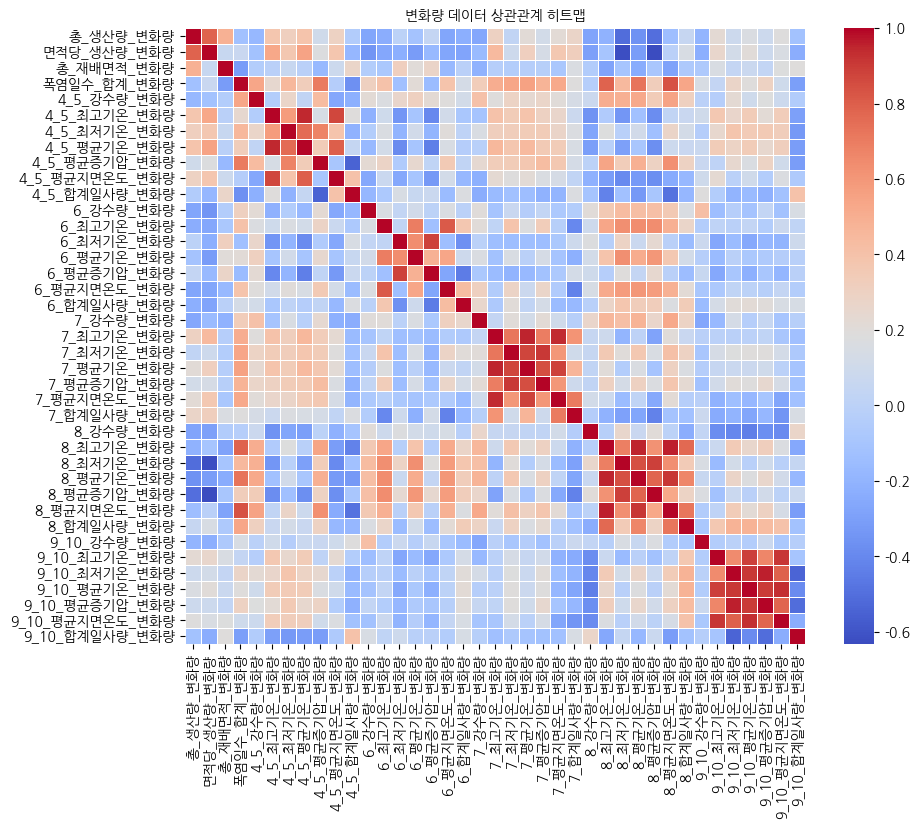

In [34]:
# 히트맵 그리기
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_changes, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)

# 한글 타이틀 설정 (필요하다면 폰트 경로 지정)
# font_path 변수가 존재하고 나눔고딕 폰트가 설치되어 있다고 가정합니다.
try:
    font_path = fm.findfont(fm.FontProperties(family='NanumGothic'))
    plt.rc('font', family='NanumGothic') # <-- 폰트 설정 다시 확인
    plt.rcParams['axes.unicode_minus'] = False # <-- 마이너스 기호 지원 추가
    plt.title('변화량 데이터 상관관계 히트맵', fontproperties=fm.FontProperties(fname=font_path))
except:
    plt.title('Correlation Heatmap of Change Data')
    print("나눔고딕 폰트 경로를 찾을 수 없어 기본 폰트로 표시합니다.")


# 히트맵 표시
plt.show()

In [35]:
# '총_생산량'과의 상관계수만 추출
corr_target_changes = correlation_matrix_changes['총_생산량_변화량']

# 절댓값 0.3 이상 필터링
strong_corr_changes = corr_target_changes[abs(corr_target_changes) >= 0.3]

strong_corr_changes

,총_생산량_변화량
총_생산량_변화량,1.000000
면적당_생산량_변화량,0.788429
총_재배면적_변화량,0.487002
4_5_최고기온_변화량,0.376637
4_5_최저기온_변화량,0.317009
4_5_평균기온_변화량,0.392771
8_최저기온_변화량,-0.508581
8_평균기온_변화량,-0.360585
8_평균증기압_변화량,-0.501474


In [36]:
#변화량 확인

print('원본 상관관계')
print(strong_corr)
print('변화량 상관관계')
print(strong_corr_changes)


원본 상관관계
총_생산량          1.000000
총_재배면적         0.986296
4_5_최저기온       0.352232
4_5_평균증기압      0.538910
6_최고기온        -0.401065
6_최저기온         0.382303
6_평균증기압        0.509120
7_최저기온         0.342732
7_평균증기압        0.440023
8_최저기온         0.366599
8_평균증기압        0.405312
9_10_최저기온      0.417552
9_10_평균기온      0.422987
9_10_평균증기압     0.362559
9_10_평균지면온도    0.449559
Name: 총_생산량, dtype: float64
변화량 상관관계
총_생산량_변화량       1.000000
면적당_생산량_변화량     0.788429
총_재배면적_변화량      0.487002
4_5_최고기온_변화량    0.376637
4_5_최저기온_변화량    0.317009
4_5_평균기온_변화량    0.392771
8_최저기온_변화량     -0.508581
8_평균기온_변화량     -0.360585
8_평균증기압_변화량    -0.501474
Name: 총_생산량_변화량, dtype: float64


# 회귀분석

## 변화량 회귀분석

In [37]:
import statsmodels.api as sm

# 독립 변수 (기후 요인 변화량) 및 종속 변수 (총 생산량 변화량) 정의
# 변화량 데이터프레임에서 필요한 컬럼 선택
df_regression_data = df_final_changes[['총_생산량_변화량', '4_5_최고기온_변화량', '4_5_최저기온_변화량', '4_5_평균기온_변화량', '8_최저기온_변화량', '8_평균기온_변화량', '8_평균증기압_변화량']].copy()

# NaN 값이 있는 행 제거 (단계적 회귀분석을 위해)
df_regression_data = df_regression_data.dropna()

# 종속 변수 (y)와 독립 변수 (X) 설정
y = df_regression_data['총_생산량_변화량']
X = df_regression_data[['4_5_최고기온_변화량', '4_5_최저기온_변화량', '4_5_평균기온_변화량', '8_최저기온_변화량', '8_평균기온_변화량', '8_평균증기압_변화량']]

# 상수항 추가 (회귀 모델에 절편을 포함시키기 위해)
X = sm.add_constant(X)

print("회귀 분석에 사용될 데이터의 처음 5개 행:")
display(df_regression_data.head())

print("\n회귀 분석 데이터 정보:")
df_regression_data.info()

print("\n종속 변수 (y) 정보:")
print(y.head())

print("\n독립 변수 (X) 정보:")
print(X.head())

회귀 분석에 사용될 데이터의 처음 5개 행:


,총_생산량_변화량,4_5_최고기온_변화량,4_5_최저기온_변화량,4_5_평균기온_변화량,8_최저기온_변화량,8_평균기온_변화량,8_평균증기압_변화량
0,-11272.138490,0.060656,0.128962,-0.213388,0.673118,1.318939,0.639736
1,11994.691107,1.974863,0.846995,1.914829,-1.912903,-2.328006,-2.178788
2,7223.673077,0.926776,-0.043716,0.765077,-1.187097,-0.229211,-0.668817
3,-3368.451427,1.548634,0.170492,1.041708,-0.748387,0.634767,0.133692
4,-23873.078320,0.316393,0.419672,0.422360,0.181720,-0.618762,0.206989



회귀 분석 데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   총_생산량_변화량     96 non-null     float64
 1   4_5_최고기온_변화량  96 non-null     float64
 2   4_5_최저기온_변화량  96 non-null     float64
 3   4_5_평균기온_변화량  96 non-null     float64
 4   8_최저기온_변화량    96 non-null     float64
 5   8_평균기온_변화량    96 non-null     float64
 6   8_평균증기압_변화량   96 non-null     float64
dtypes: float64(7)
memory usage: 5.4 KB

종속 변수 (y) 정보:
0   -11272.138490
1    11994.691107
2     7223.673077
3    -3368.451427
4   -23873.078320
Name: 총_생산량_변화량, dtype: float64

독립 변수 (X) 정보:
   const  4_5_최고기온_변화량  4_5_최저기온_변화량  4_5_평균기온_변화량  8_최저기온_변화량  8_평균기온_변화량  \
0    1.0      0.060656      0.128962     -0.213388    0.673118    1.318939   
1    1.0      1.974863      0.846995      1.914829   -1.912903   -2.328006   
2    1.0      0.926776     -0.043716      0.765077   -1.187097   -0.22

In [38]:
# OLS(Ordinary Least Squares) 회귀 모델 적합
# 종속 변수 y와 독립 변수 X를 사용하여 모델을 생성하고 적합시킵니다.
model = sm.OLS(y, X).fit()

# 회귀 분석 결과 요약 출력
print("단계적 회귀 분석 결과:")
print(model.summary())

단계적 회귀 분석 결과:
                            OLS Regression Results                            
Dep. Variable:              총_생산량_변화량   R-squared:                       0.362
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     8.414
Date:                Sun, 14 Dec 2025   Prob (F-statistic):           3.11e-07
Time:                        02:26:56   Log-Likelihood:                -1105.7
No. Observations:                  96   AIC:                             2225.
Df Residuals:                      89   BIC:                             2243.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -9987.1763   2913.098

## 원본 데이터 회귀분석

In [39]:

# 독립 변수 (기후 요인 변화량) 및 종속 변수 (총 생산량 변화량) 정의
# 변화량 데이터프레임에서 필요한 컬럼 선택
df_regression_data_before = df_merged[['총_생산량', '4_5_최저기온', '4_5_평균증기압', '6_최고기온', '6_최저기온', '6_평균증기압', '7_최저기온',
                                              '7_평균증기압', '8_최저기온', '8_평균증기압', '9_10_최저기온', '9_10_평균기온', '9_10_평균증기압', '9_10_평균지면온도']].copy()

# NaN 값이 있는 행 제거 (단계적 회귀분석을 위해)
df_regression_data_before = df_regression_data_before.dropna()

# 종속 변수 (y)와 독립 변수 (X) 설정
y = df_regression_data_before['총_생산량']
X = df_regression_data_before[['4_5_최저기온', '4_5_평균증기압', '6_최고기온', '6_최저기온', '6_평균증기압', '7_최저기온',
                                              '7_평균증기압', '8_최저기온', '8_평균증기압', '9_10_최저기온', '9_10_평균기온', '9_10_평균증기압', '9_10_평균지면온도']]

# 상수항 추가 (회귀 모델에 절편을 포함시키기 위해)
X = sm.add_constant(X)

print("회귀 분석에 사용될 데이터의 처음 5개 행:")
display(df_regression_data_before.head())

print("\n회귀 분석 데이터 정보:")
df_regression_data_before.info()

print("\n종속 변수 (y) 정보:")
print(y.head())

print("\n독립 변수 (X) 정보:")
print(X.head())

회귀 분석에 사용될 데이터의 처음 5개 행:


,총_생산량,4_5_최저기온,4_5_평균증기압,6_최고기온,6_최저기온,6_평균증기압,7_최저기온,7_평균증기압,8_최저기온,8_평균증기압,9_10_최저기온,9_10_평균기온,9_10_평균증기압,9_10_평균지면온도
0,176155.99180,2.575410,8.357377,30.826667,11.003333,16.508182,17.900000,22.983871,19.280645,25.731256,7.386885,15.926093,14.482787,18.191667
1,417292.60934,6.036066,9.625574,29.716667,16.460000,18.668333,21.425806,25.822581,22.058065,28.267258,10.942623,16.883934,15.734754,19.031148
2,404127.72499,7.578689,10.515925,29.480000,16.406667,18.502698,21.041935,26.343369,22.900000,29.511828,11.852459,19.426047,17.090528,21.429690
3,590301.31853,3.532787,9.033681,30.926667,12.770000,17.276970,19.029032,24.295601,20.812903,27.475978,9.085246,17.246543,15.921133,19.651258
4,846034.55331,6.509836,11.025246,28.610000,15.746667,19.539333,20.545161,27.001613,22.841935,30.430968,12.972131,19.318525,17.738197,21.405246



회귀 분석 데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   총_생산량        120 non-null    float64
 1   4_5_최저기온     120 non-null    float64
 2   4_5_평균증기압    120 non-null    float64
 3   6_최고기온       120 non-null    float64
 4   6_최저기온       120 non-null    float64
 5   6_평균증기압      120 non-null    float64
 6   7_최저기온       120 non-null    float64
 7   7_평균증기압      120 non-null    float64
 8   8_최저기온       120 non-null    float64
 9   8_평균증기압      120 non-null    float64
 10  9_10_최저기온    120 non-null    float64
 11  9_10_평균기온    120 non-null    float64
 12  9_10_평균증기압   120 non-null    float64
 13  9_10_평균지면온도  120 non-null    float64
dtypes: float64(14)
memory usage: 13.3 KB

종속 변수 (y) 정보:
0    176155.99180
1    417292.60934
2    404127.72499
3    590301.31853
4    846034.55331
Name: 총_생산량, dtype: float64

독립 변수 (X) 정보:
   const  4_5_최저기온

In [40]:
# OLS(Ordinary Least Squares) 회귀 모델 적합
# 종속 변수 y와 독립 변수 X를 사용하여 모델을 생성하고 적합시킵니다.
model = sm.OLS(y, X).fit()

# 회귀 분석 결과 요약 출력
print("단계적 회귀 분석 결과:")
print(model.summary())

단계적 회귀 분석 결과:
                            OLS Regression Results                            
Dep. Variable:                  총_생산량   R-squared:                       0.489
Model:                            OLS   Adj. R-squared:                  0.426
Method:                 Least Squares   F-statistic:                     7.798
Date:                Sun, 14 Dec 2025   Prob (F-statistic):           1.14e-10
Time:                        02:26:57   Log-Likelihood:                -1610.8
No. Observations:                 120   AIC:                             3250.
Df Residuals:                     106   BIC:                             3289.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        1.078e+06   8.95e+05   

# AI 모델 - 랜덤포레스트, XGB, SHAP

## 원본데이터 모델

In [84]:
# 타깃
y = df_regression_data_before['총_생산량']

# 입력 변수 (기후 변수만)
X = df_regression_data_before.drop(columns=['총_생산량'])

In [85]:
# 타깃
y = df_numeric['총_생산량']

# 입력 변수 (기후 변수만)
X = df_numeric.drop(columns=['총_생산량', '총_재배면적', '면적당_생산량'])


In [97]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import mean_squared_error
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features=0.6,
    random_state=42,
    n_jobs=-1
  )

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)



print("RF R²:", r2_score(y_test, y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RF RMSE:", rmse)

print("RF Train R2:", r2_score(y_train, rf.predict(X_train)))
print("RF Test R2:", r2_score(y_test, y_pred))

RF R²: 0.4241215213778229
RF RMSE: 178149.14603232464
RF Train R2: 0.7247450607555547
RF Test R2: 0.4241215213778229


In [94]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=80,
    learning_rate=0.05,
    max_depth=2,
    min_child_weight=10,
    gamma=0.1,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGB R²:", r2_score(y_test, y_pred_xgb))
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print("XGB RMSE:", rmse_xgb)

print("XGB Train R2:", r2_score(y_train, xgb.predict(X_train)))
print("XGB Test R2:", r2_score(y_test, y_pred_xgb))

XGB R²: 0.37182680205512764
XGB RMSE: 186062.1443411382
XGB Train R2: 0.7932737694855281
XGB Test R2: 0.37182680205512764


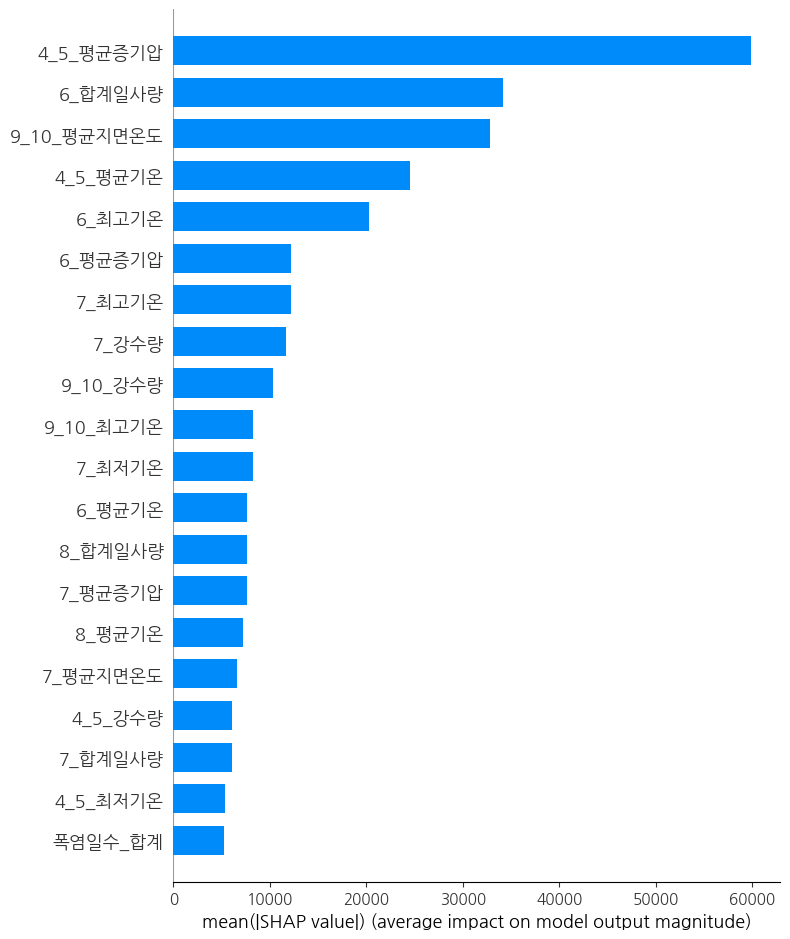

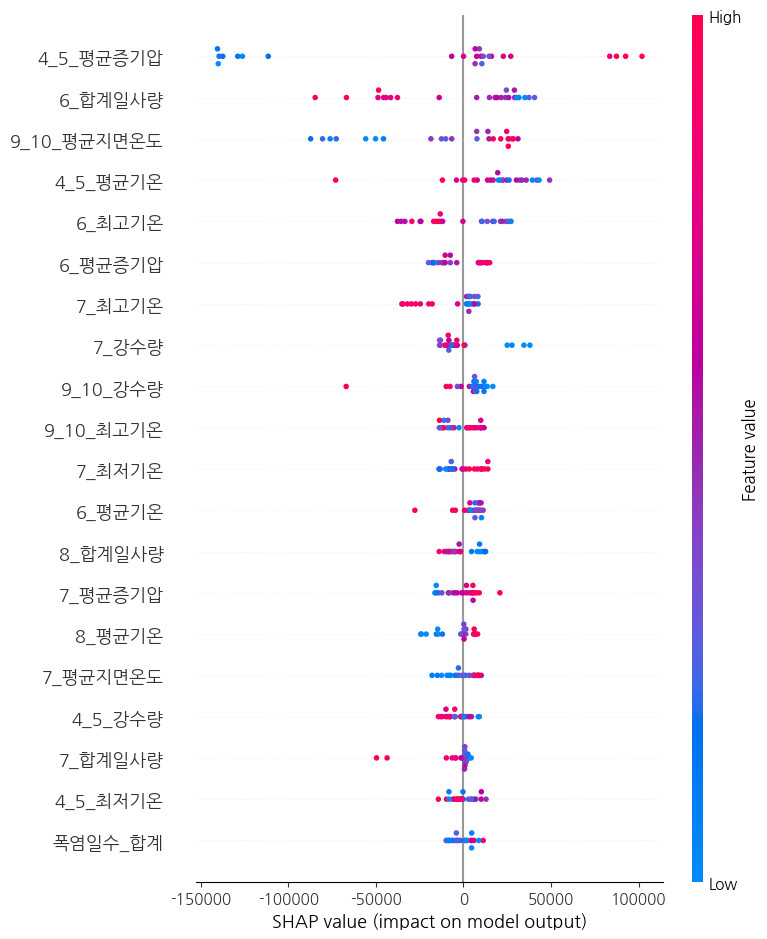

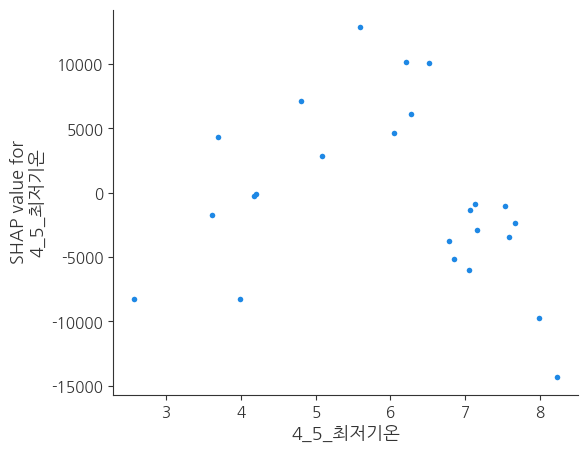

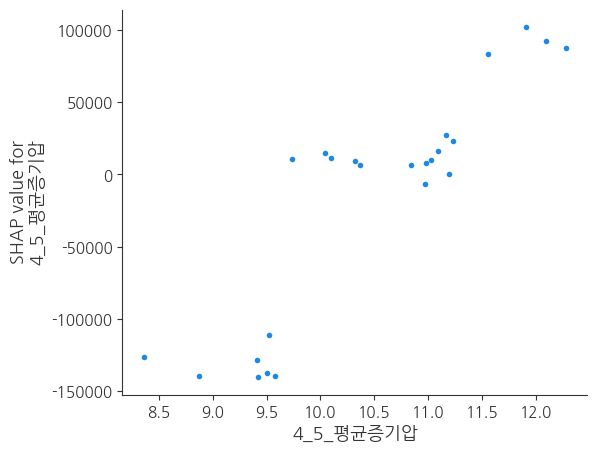

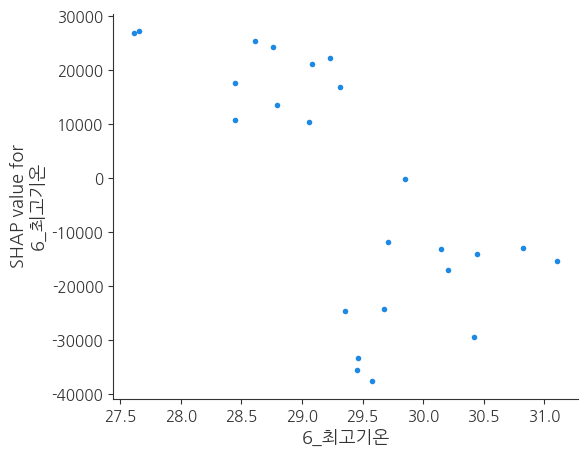

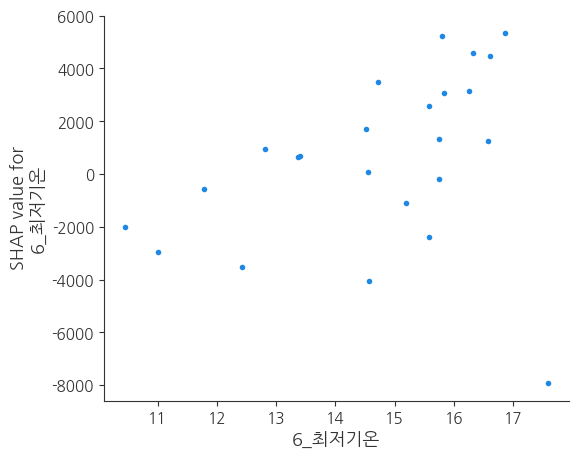

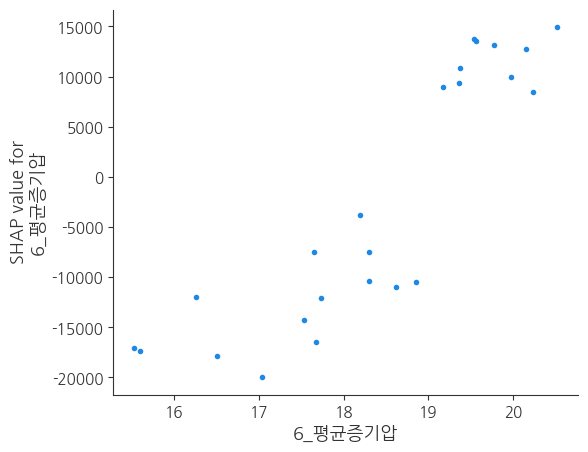

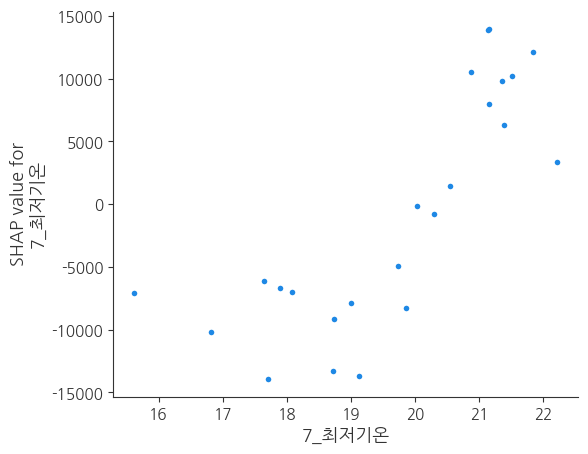

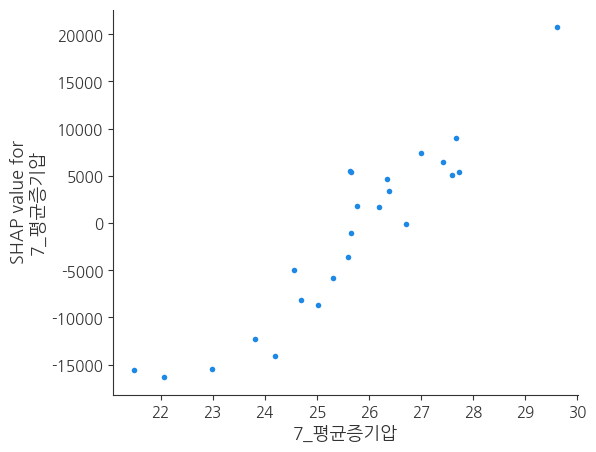

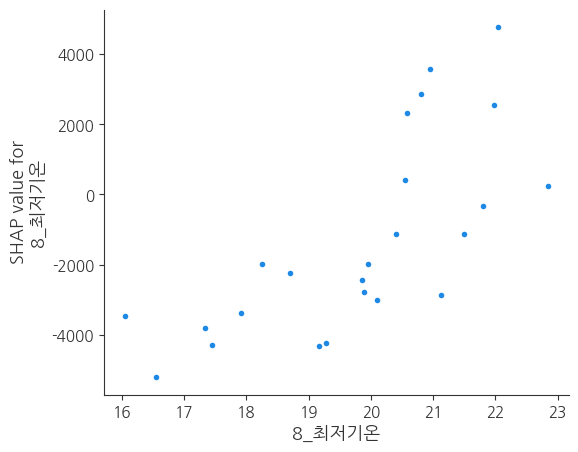

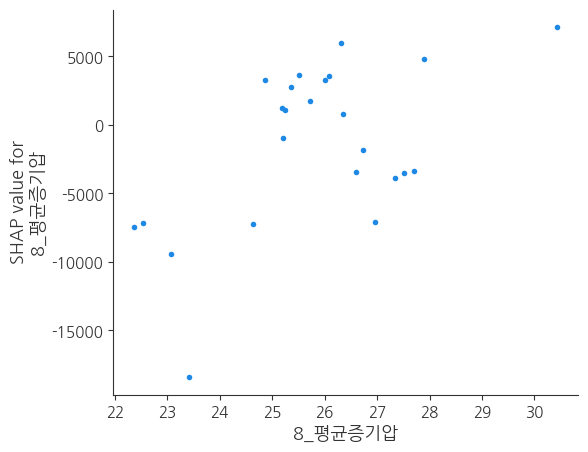

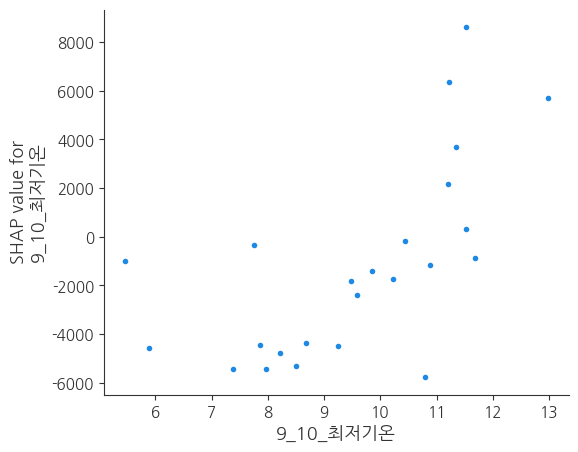

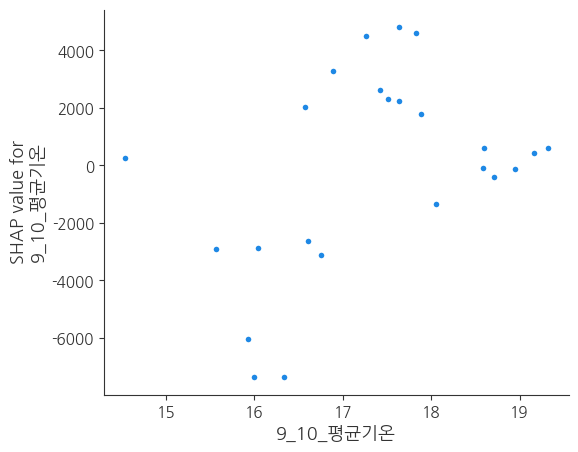

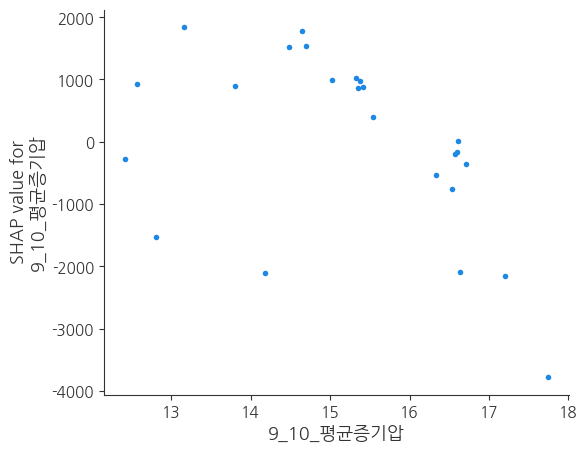

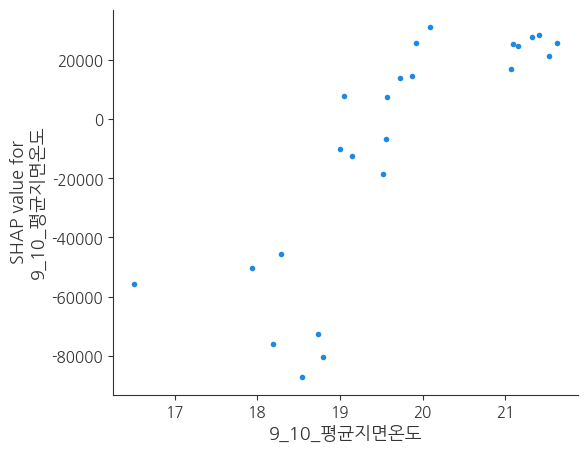

In [56]:
import shap

explainer = shap.Explainer(xgb, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")

shap.summary_plot(shap_values, X_test)

shap.dependence_plot("4_5_최저기온", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("4_5_평균증기압", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("6_최고기온", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("6_최저기온", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("6_평균증기압", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("7_최저기온", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("7_평균증기압", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("8_최저기온", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("8_평균증기압", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("9_10_최저기온", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("9_10_평균기온", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("9_10_평균증기압", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("9_10_평균지면온도", shap_values.values, X_test, interaction_index=None)

## 변화량 **모델**

In [67]:
# 타깃
y = df_numeric_changes['총_생산량_변화량']

# 입력 변수 (기후 변수만)
X = df_numeric_changes.drop(columns=['총_생산량_변화량', '총_재배면적_변화량', '면적당_생산량_변화량'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features=0.6,
    random_state=42,
    n_jobs=-1
  )


rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)



print("RF R²:", r2_score(y_test, y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RF RMSE:", rmse)

print("RF Train R2:", r2_score(y_train, rf.predict(X_train)))
print("RF Test R2:", r2_score(y_test, y_pred))

RF R²: 0.5460013543322316
RF RMSE: 21029.730777289813
RF Train R2: 0.6759212437759073
RF Test R2: 0.5460013543322316


In [81]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=80,
    learning_rate=0.05,
    max_depth=2,
    min_child_weight=10,
    gamma=0.1,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGB R²:", r2_score(y_test, y_pred_xgb))
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print("XGB RMSE:", rmse_xgb)
print("XGB Train R2:", r2_score(y_train, xgb.predict(X_train)))
print("XGB Test R2:", r2_score(y_test, y_pred_xgb))

XGB R²: 0.5637078693508658
XGB RMSE: 20615.55941362663
XGB Train R2: 0.7800352087926588
XGB Test R2: 0.5637078693508658


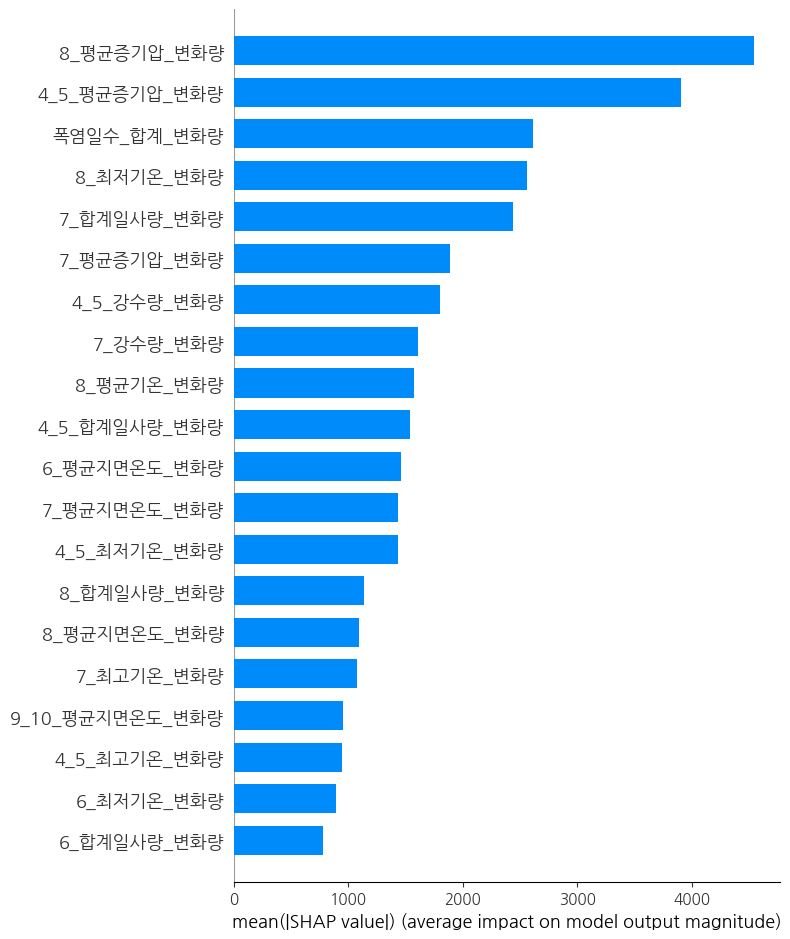

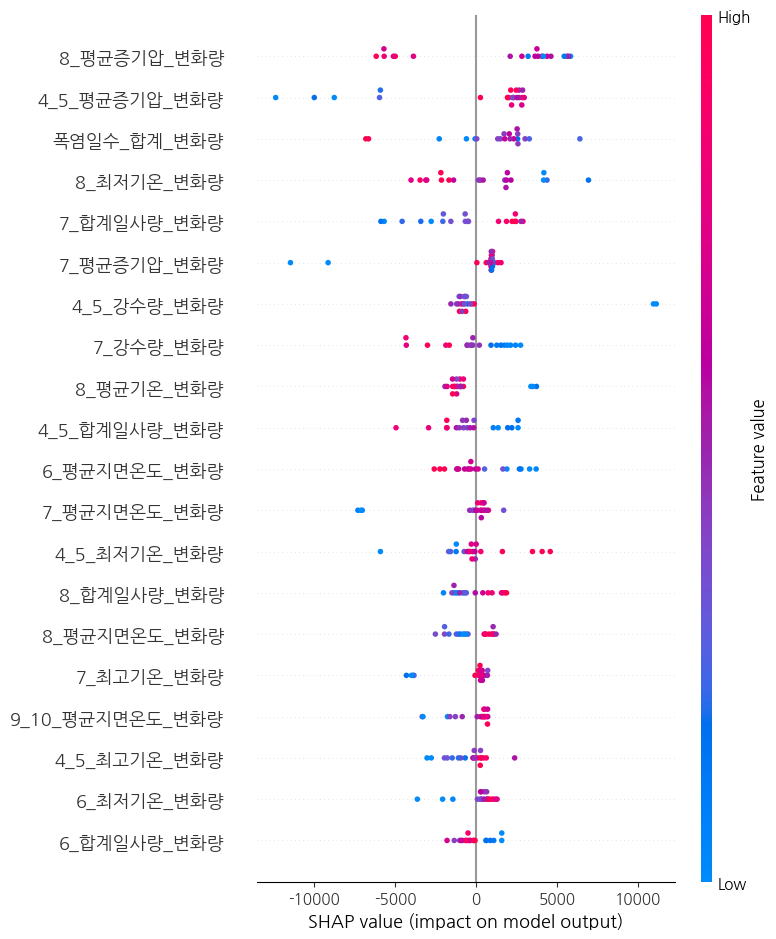

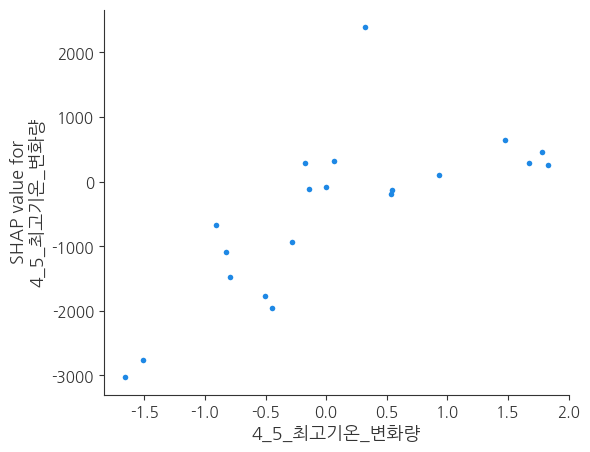

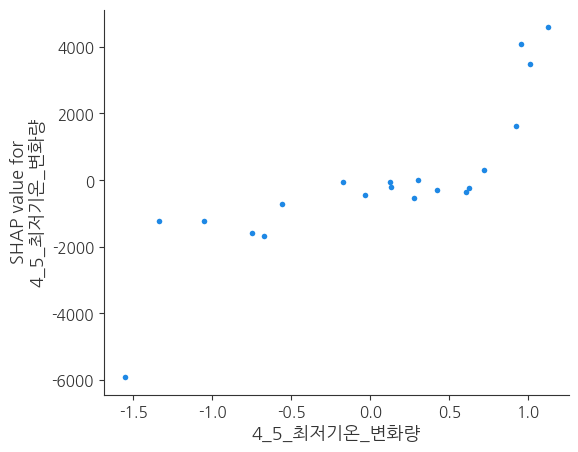

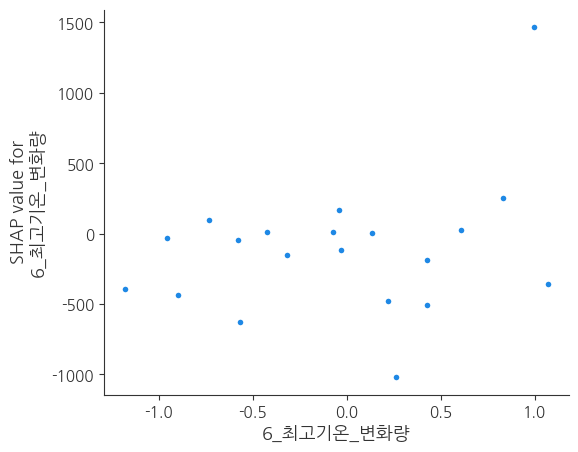

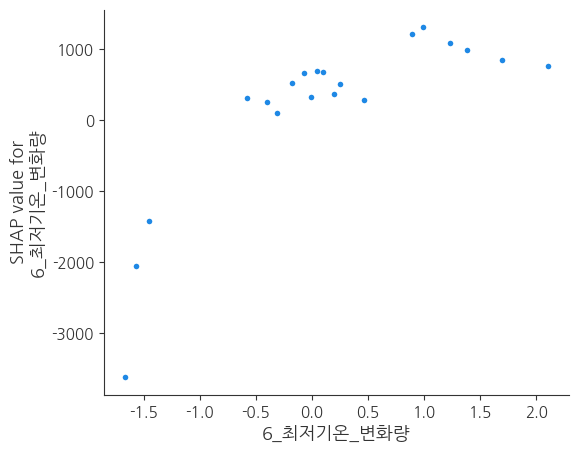

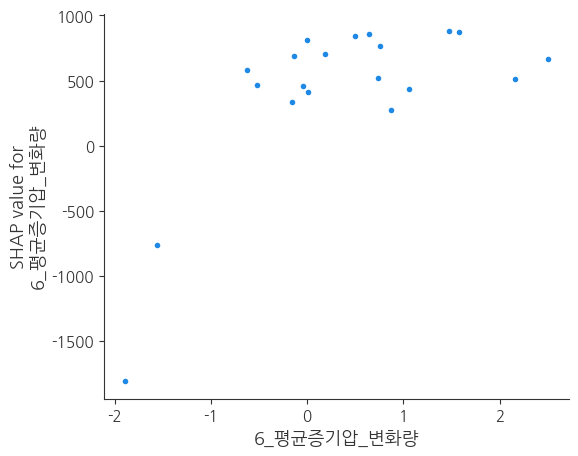

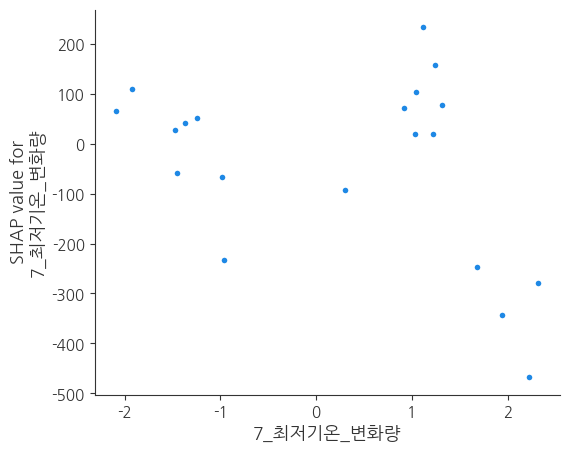

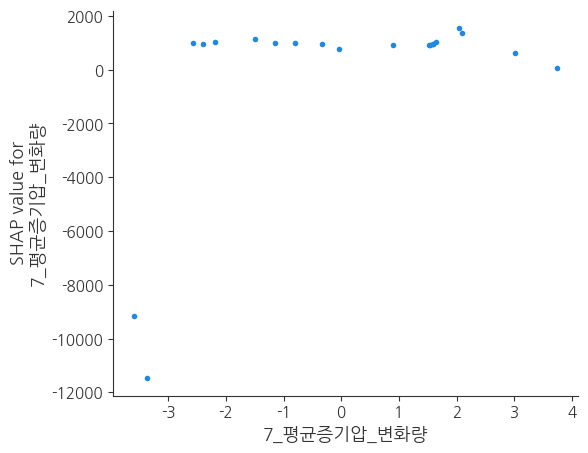

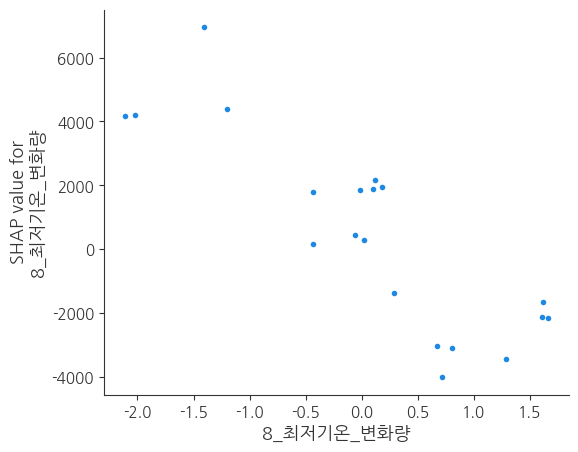

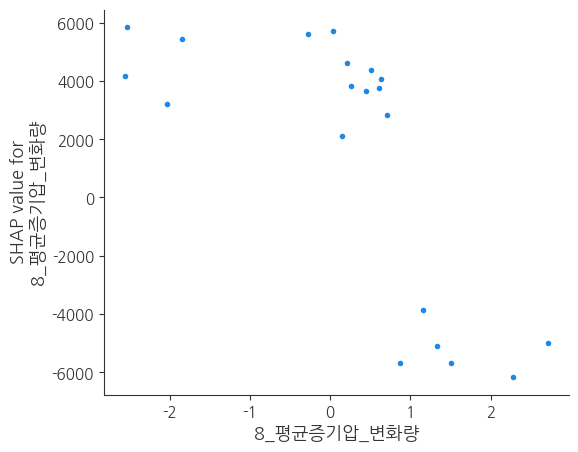

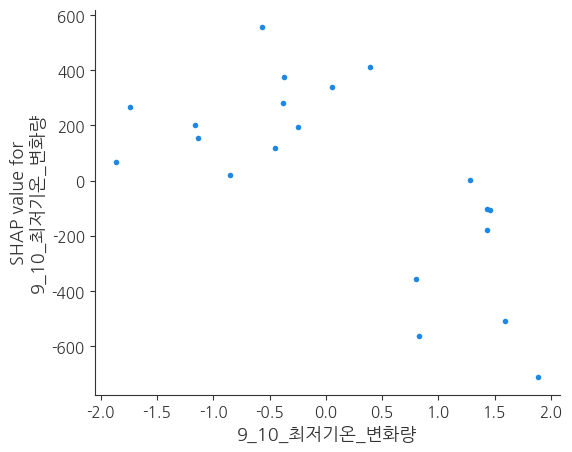

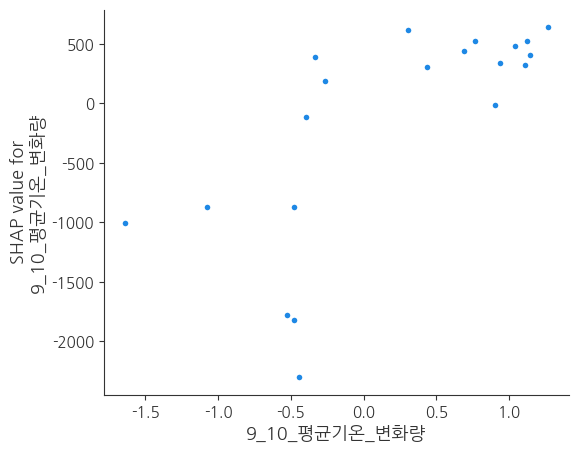

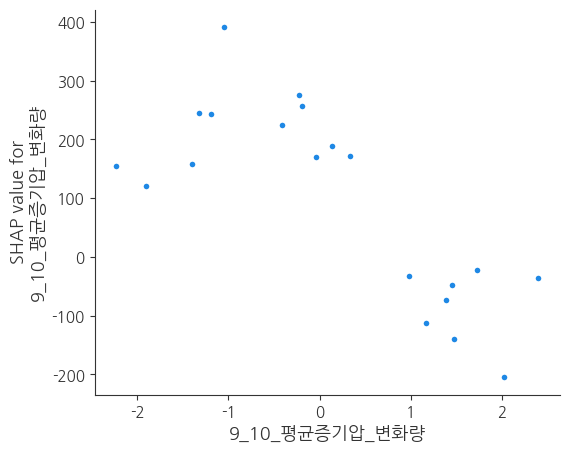

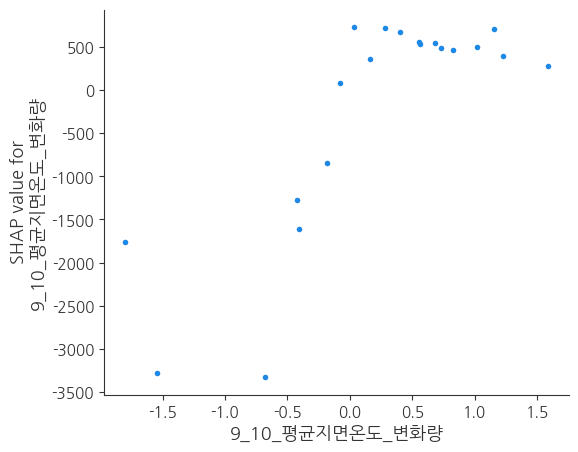

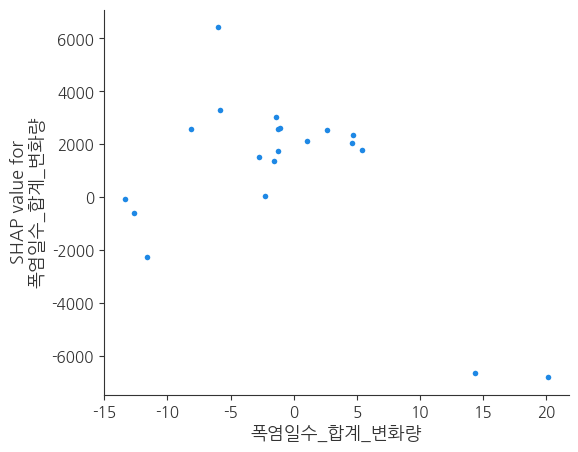

In [60]:
import shap

explainer = shap.Explainer(xgb, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")

shap.summary_plot(shap_values, X_test)

shap.dependence_plot("4_5_최고기온_변화량", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("4_5_최저기온_변화량", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("6_최고기온_변화량", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("6_최저기온_변화량", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("6_평균증기압_변화량", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("7_최저기온_변화량", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("7_평균증기압_변화량", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("8_최저기온_변화량", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("8_평균증기압_변화량", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("9_10_최저기온_변화량", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("9_10_평균기온_변화량", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("9_10_평균증기압_변화량", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("9_10_평균지면온도_변화량", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("폭염일수_합계_변화량", shap_values.values, X_test, interaction_index=None)